# **Proyecto Integrador de Deep Learning: Avazu Click-Through Rate Prediction**

En este proyecto de integrador se busca construir un modelo de clasificación supervisada usando MLP (Multilayer Perceptron/Red Neuronal Multicapa) para predecir si un usuario hará clic en un anuncio móvil (click = 1) o no (click = 0). Se comparará el desempeño de los modelos construidos con scikit-learn y PySpark. Además, se aplicará LIME para interpretar predicciones individuales del modelo.

## **Diccionario de Datos: Dataset Avazu CTR**

| Variable            | Tipo de Dato | Descripción |
|--------------------|-------------|------------|
| id                 | float64     | Identificador único de la impresión del anuncio. |
| click              | int64       | Variable objetivo: 0 si no hubo clic, 1 si hubo clic. |
| hour               | int64       | Formato AAMMDDHH (Año, Mes, Día, Hora). |
| C1                 | int64       | Variable categórica anonimizada. |
| banner_pos         | int64       | Posición del banner en la página/app (0, 1, 2...). |
| site_id            | object      | ID único del sitio web donde se mostró el anuncio. |
| site_domain        | object      | Dominio del sitio web. |
| site_category      | object      | Categoría del sitio (noticias, deportes, etc.). |
| app_id             | object      | ID de la aplicación móvil. |
| app_domain         | object      | Dominio de la aplicación. |
| app_category       | object      | Categoría de la aplicación (juegos, utilidades, etc.). |
| device_id          | object      | ID único del dispositivo físico. |
| device_ip          | object      | Dirección IP del dispositivo. |
| device_model       | object      | Modelo del dispositivo (ej. iPhone, Samsung). |
| device_type        | int64       | Tipo de dispositivo (categoría numérica). |
| device_conn_type   | int64       | Tipo de conexión (WiFi, datos móviles, etc.). |
| C14                | int64       | Variable categórica anonimizada. |
| C15                | int64       | Variable categórica anonimizada. |
| C16                | int64       | Variable categórica anonimizada. |
| C17                | int64       | Variable categórica anonimizada. |
| C18                | int64       | Variable categórica anonimizada. |
| C19                | int64       | Variable categórica anonimizada. |
| C20                | int64       | Variable categórica anonimizada. |
| C21                | int64       | Variable categórica anonimizada. |

## **1. Cargar y observar datos**

Inicialmente se importan las librerías necesarias para analizar los datos. Asimismo, se importan los datos del proyecto integrador y se observan los datos para tener un visión general de estos.

### ***1.1. Importar librerías***

In [1]:
import sklearn
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPClassifier
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split
import numpy as np
from pyspark.sql import SparkSession
import os
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2, SelectKBest

### ***1.2. Cargar el dataset***

In [2]:
df = pd.read_csv("train.csv")

### ***1.3. Observación del dataset***

In [3]:
pd.set_option('display.max_columns', None)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40428967 entries, 0 to 40428966
Data columns (total 24 columns):
 #   Column            Dtype  
---  ------            -----  
 0   id                float64
 1   click             int64  
 2   hour              int64  
 3   C1                int64  
 4   banner_pos        int64  
 5   site_id           object 
 6   site_domain       object 
 7   site_category     object 
 8   app_id            object 
 9   app_domain        object 
 10  app_category      object 
 11  device_id         object 
 12  device_ip         object 
 13  device_model      object 
 14  device_type       int64  
 15  device_conn_type  int64  
 16  C14               int64  
 17  C15               int64  
 18  C16               int64  
 19  C17               int64  
 20  C18               int64  
 21  C19               int64  
 22  C20               int64  
 23  C21               int64  
dtypes: float64(1), int64(14), object(9)
memory usage: 7.2+ GB


La base de datos contiene más de 40.04 millones de registros organizados en 24 columnas con datos numéricos y categóricos.

In [5]:
df.head()

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,device_id,device_ip,device_model,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
0,1.000009e+18,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,ddd2926e,44956a24,1,2,15706,320,50,1722,0,35,-1,79
1,1.000017e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,96809ac8,711ee120,1,0,15704,320,50,1722,0,35,100084,79
2,1.000037e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,b3cf8def,8a4875bd,1,0,15704,320,50,1722,0,35,100084,79
3,1.000064e+19,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,a99f214a,e8275b8f,6332421a,1,0,15706,320,50,1722,0,35,100084,79
4,1.000068e+19,0,14102100,1005,1,fe8cc448,9166c161,0569f928,ecad2386,7801e8d9,07d7df22,a99f214a,9644d0bf,779d90c2,1,0,18993,320,50,2161,0,35,-1,157


## ***2. Verificación  valores faltantes y tipos de datos***

Luego, en esta sección, se verifica los tipos de datos que se le asignaron de manera automática a cada variable y los datos faltantes de cada una.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40428967 entries, 0 to 40428966
Data columns (total 24 columns):
 #   Column            Dtype  
---  ------            -----  
 0   id                float64
 1   click             int64  
 2   hour              int64  
 3   C1                int64  
 4   banner_pos        int64  
 5   site_id           object 
 6   site_domain       object 
 7   site_category     object 
 8   app_id            object 
 9   app_domain        object 
 10  app_category      object 
 11  device_id         object 
 12  device_ip         object 
 13  device_model      object 
 14  device_type       int64  
 15  device_conn_type  int64  
 16  C14               int64  
 17  C15               int64  
 18  C16               int64  
 19  C17               int64  
 20  C18               int64  
 21  C19               int64  
 22  C20               int64  
 23  C21               int64  
dtypes: float64(1), int64(14), object(9)
memory usage: 7.2+ GB


En la anterior salida de código, se puede observar que hay algunas variables categóricas que se encuentran tipificadas como numéricas, por lo que se hace la correción.

In [7]:
cols_a_convertir = ['id', 'C1', 'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21','device_type', 'device_conn_type', 'click', 'banner_pos']

for col in cols_a_convertir:
    if col in df.columns:
        df[col] = df[col].astype(object)

Además, eliminamos variables como `device_ip` y `id` debido a que estos son identificadores únicos y al momento de modelar solo aumentaría la cardinalidad y el ruido de la base de datos.

In [8]:
cols_a_eliminar = ['device_ip', 'device_id', 'id']
df.drop(columns=cols_a_eliminar, inplace=True)

Luego, se verifican los valores faltantes de todas las variables.

In [9]:
null_counts = df.isnull().sum()
null_percentages = (null_counts / len(df)) * 100

print("--- Valores faltantes por columna ---")
print(pd.concat([null_counts, null_percentages], axis=1, keys=['Total', '%']))

--- Valores faltantes por columna ---
                  Total    %
click                 0  0.0
hour                  0  0.0
C1                    0  0.0
banner_pos            0  0.0
site_id               0  0.0
site_domain           0  0.0
site_category         0  0.0
app_id                0  0.0
app_domain            0  0.0
app_category          0  0.0
device_model          0  0.0
device_type           0  0.0
device_conn_type      0  0.0
C14                   0  0.0
C15                   0  0.0
C16                   0  0.0
C17                   0  0.0
C18                   0  0.0
C19                   0  0.0
C20                   0  0.0
C21                   0  0.0


Aunque se muestra que no hay valores faltantes en la base de datos, se puede notar en `df.hea()` que la variable `C20` toma valores -1, que pueden indicar valores faltante, por lo que se verifica este caso.

In [10]:
df['C20'].unique()

array([-1, 100084, 100077, 100191, 100019, 100148, 100088, 100083, 100217,
       100111, 100193, 100034, 100075, 100228, 100131, 100188, 100202,
       100021, 100200, 100050, 100063, 100000, 100081, 100057, 100003,
       100130, 100076, 100079, 100233, 100128, 100106, 100060, 100002,
       100074, 100020, 100156, 100046, 100005, 100105, 100013, 100028,
       100215, 100119, 100173, 100210, 100221, 100161, 100189, 100048,
       100151, 100190, 100049, 100062, 100194, 100241, 100248, 100224,
       100026, 100103, 100205, 100160, 100212, 100041, 100070, 100138,
       100185, 100225, 100065, 100037, 100029, 100199, 100101, 100094,
       100162, 100171, 100192, 100095, 100052, 100087, 100086, 100126,
       100097, 100072, 100117, 100170, 100012, 100107, 100166, 100183,
       100025, 100163, 100206, 100155, 100176, 100068, 100039, 100168,
       100055, 100112, 100096, 100022, 100054, 100150, 100122, 100149,
       100001, 100177, 100141, 100213, 100043, 100010, 100139, 100137,
  

Note que efectivamente la variable `C20` toma valores **-1**, los cuales representan datos anomalos teniendo en cuenta el resto de categorías que toma la variable, por lo que se interpretan como palores faltante y se transforman a NA.

In [11]:
df["C20"] = df["C20"].replace({-1:pd.NA})

In [12]:
def resumen_faltantes(df):
    faltantes = df.isnull().sum()
    porcentaje = (faltantes / len(df)) * 100

    tabla_faltantes = pd.DataFrame({
        'Valores faltantes': faltantes,
        'Porcentaje (%)': porcentaje
    })

    # Mostrar solo columnas con NA
    tabla_faltantes = tabla_faltantes[tabla_faltantes['Valores faltantes'] > 0]
    tabla_faltantes.sort_values('Porcentaje (%)', ascending=False)
    return tabla_faltantes

Después de hacer la debida transformación de los valores faltantes, verificamos la cantidad de valores nulos resultantes.

In [13]:
resumen_faltantes(df)

,Valores faltantes,Porcentaje (%)
C20,18937918,46.842448


Dado el alto porcentaje de valores faltantes y la poco información que se tiene de la variable, realizar alguna imputación seria sesgar los datos, por lo que prescindiremos de la variable.

In [14]:
df = df.drop(columns=["C20"])

## **3. Analizar cardinalidad de las variables categóricas**

Por otra parte, se analiza la cardinalidad de las variables categóricas para evitar futuros problemas con la memoria RAM, además de evitar sobreajuste debido a que el modelo intentará aprender patrones de categorías que quizá solo aparezcan una vez.

In [15]:
def resumen_categoricas(df,col_names):
    for col in col_names:
        conteo = df[col].value_counts(dropna=False)
        porcentaje = df[col].value_counts(normalize=True, dropna=False) * 100

        resumen = pd.DataFrame({
        'categorias': conteo.index,
        'conteo': conteo.values,
        'porcentaje': porcentaje.values.round(2)
        })
        num_categorias = len(resumen)
        
        resumen = resumen.head(10)  

        styled = resumen.style \
        .set_caption(f"Distribución de {col} tiene {num_categorias} categorías") \
        .format({'porcentaje': '{:.2f}%'})

        display(styled)

In [16]:
# Seleccionamos las columnas categóricas
cat_cols = df.select_dtypes(include=['object', 'category']).columns

# Creamos un resumen de cardinalidad
cardinality = df[cat_cols].nunique().sort_values(ascending=False)

df_cardinality = pd.DataFrame({
    'Variable': cardinality.index,
    'Valores Únicos': cardinality.values,
    '% de Unicidad': (cardinality.values / len(df)) * 100
})

print("Análisis de Cardinalidad")
print(df_cardinality)

Análisis de Cardinalidad
            Variable  Valores Únicos  % de Unicidad
0             app_id            8552       0.021153
1       device_model            8251       0.020409
2        site_domain            7745       0.019157
3            site_id            4737       0.011717
4                C14            2626       0.006495
5         app_domain             559       0.001383
6                C17             435       0.001076
7                C19              68       0.000168
8                C21              60       0.000148
9       app_category              36       0.000089
10     site_category              26       0.000064
11               C16               9       0.000022
12               C15               8       0.000020
13                C1               7       0.000017
14        banner_pos               7       0.000017
15       device_type               5       0.000012
16  device_conn_type               4       0.000010
17               C18               4   

Observe que hay variables que sobrepasan de más de 400 categorías, por lo que se observa cada variable para determinar cómo tratar la alta cardinalidad.

In [17]:
resumen_categoricas(df,cat_cols)

,categorias,conteo,porcentaje
0,0,33563901,83.02%
1,1,6865066,16.98%


,categorias,conteo,porcentaje
0,1005,37140632,91.87%
1,1002,2220812,5.49%
2,1010,903457,2.23%
3,1012,113512,0.28%
4,1007,35304,0.09%
5,1001,9463,0.02%
6,1008,5787,0.01%


,categorias,conteo,porcentaje
0,0,29109590,72.00%
1,1,11247282,27.82%
2,7,43577,0.11%
3,2,13001,0.03%
4,4,7704,0.02%
5,5,5778,0.01%
6,3,2035,0.01%


,categorias,conteo,porcentaje
0,85f751fd,14596137,36.10%
1,1fbe01fe,6486150,16.04%
2,e151e245,2637747,6.52%
3,d9750ee7,963745,2.38%
4,5b08c53b,913325,2.26%
5,5b4d2eda,771360,1.91%
6,856e6d3f,765891,1.89%
7,a7853007,461311,1.14%
8,b7e9786d,369099,0.91%
9,5ee41ff2,349008,0.86%


,categorias,conteo,porcentaje
0,c4e18dd6,15131739,37.43%
1,f3845767,6486150,16.04%
2,7e091613,3325008,8.22%
3,7687a86e,1290165,3.19%
4,98572c79,996816,2.47%
5,16a36ef3,855686,2.12%
6,58a89a43,765891,1.89%
7,9d54950b,375891,0.93%
8,b12b9f85,373925,0.92%
9,17d996e6,353600,0.87%


...

,categorias,conteo,porcentaje
0,50,38136554,94.33%
1,250,1806334,4.47%
2,36,298794,0.74%
3,480,103365,0.26%
4,90,74533,0.18%
5,20,3069,0.01%
6,768,2560,0.01%
7,320,2137,0.01%
8,1024,1621,0.00%


,categorias,conteo,porcentaje
0,1722,4513492,11.16%
1,2424,1531071,3.79%
2,2227,1473105,3.64%
3,1800,1190161,2.94%
4,423,948215,2.35%
5,2480,918663,2.27%
6,2502,855087,2.12%
7,2528,824907,2.04%
8,2506,803166,1.99%
9,2374,756358,1.87%


,categorias,conteo,porcentaje
0,0,16939044,41.90%
1,3,13654242,33.77%
2,2,7116058,17.60%
3,1,2719623,6.73%


,categorias,conteo,porcentaje
0,35,12170630,30.10%
1,39,8829426,21.84%
2,167,3145695,7.78%
3,161,1587765,3.93%
4,47,1451708,3.59%
5,1327,1092601,2.70%
6,297,1014859,2.51%
7,163,926864,2.29%
8,175,811516,2.01%
9,679,737468,1.82%


,categorias,conteo,porcentaje
0,23,8896205,22.00%
1,221,5051245,12.49%
2,79,4614799,11.41%
3,48,2160794,5.34%
4,71,2108496,5.22%
5,61,2053636,5.08%
6,157,1856105,4.59%
7,32,1783343,4.41%
8,33,1497559,3.70%
9,52,1203050,2.98%


El anterior análisis de frecuencia revela una alta concentración de los datos en las categorías principales; de hecho, a partir de la décima categoría, la representatividad cae por debajo del 2%. Por esta razón, se decide conservar únicamente las 100 categorías más frecuentes en variables de alta cardinalidad, asegurando que el modelo capture los patrones más significativos sin incurrir en un subajuste (underfitting) por pérdida excesiva de información.

In [18]:
vars_a_reducir = ['app_id', 'site_id', 'device_model', 'site_domain', 'app_domain', 'C14', 'C17']

for col in vars_a_reducir:
    top_100 = df[col].value_counts().head(100).index
    df[col] = df[col].where(df[col].isin(top_100), 'Otros')

In [19]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns

cardinality = df[cat_cols].nunique().sort_values(ascending=False)

df_cardinality = pd.DataFrame({
    'Variable': cardinality.index,
    'Valores Únicos': cardinality.values,
    '% de Unicidad': (cardinality.values / len(df)) * 100
})

print("--- Análisis de Cardinalidad ---")
print(df_cardinality)

--- Análisis de Cardinalidad ---
            Variable  Valores Únicos  % de Unicidad
0       device_model             101       0.000250
1                C14             101       0.000250
2            site_id             101       0.000250
3        site_domain             101       0.000250
4                C17             101       0.000250
5             app_id             101       0.000250
6         app_domain             101       0.000250
7                C19              68       0.000168
8                C21              60       0.000148
9       app_category              36       0.000089
10     site_category              26       0.000064
11               C16               9       0.000022
12               C15               8       0.000020
13                C1               7       0.000017
14        banner_pos               7       0.000017
15       device_type               5       0.000012
16  device_conn_type               4       0.000010
17               C18           

In [20]:
col_cat_names = df.select_dtypes(include="object").columns.tolist()

resumen_categoricas(df,col_cat_names)

,categorias,conteo,porcentaje
0,0,33563901,83.02%
1,1,6865066,16.98%


,categorias,conteo,porcentaje
0,1005,37140632,91.87%
1,1002,2220812,5.49%
2,1010,903457,2.23%
3,1012,113512,0.28%
4,1007,35304,0.09%
5,1001,9463,0.02%
6,1008,5787,0.01%


,categorias,conteo,porcentaje
0,0,29109590,72.00%
1,1,11247282,27.82%
2,7,43577,0.11%
3,2,13001,0.03%
4,4,7704,0.02%
5,5,5778,0.01%
6,3,2035,0.01%


,categorias,conteo,porcentaje
0,85f751fd,14596137,36.10%
1,1fbe01fe,6486150,16.04%
2,Otros,3647049,9.02%
3,e151e245,2637747,6.52%
4,d9750ee7,963745,2.38%
5,5b08c53b,913325,2.26%
6,5b4d2eda,771360,1.91%
7,856e6d3f,765891,1.89%
8,a7853007,461311,1.14%
9,b7e9786d,369099,0.91%


,categorias,conteo,porcentaje
0,c4e18dd6,15131739,37.43%
1,f3845767,6486150,16.04%
2,7e091613,3325008,8.22%
3,Otros,2540444,6.28%
4,7687a86e,1290165,3.19%
5,98572c79,996816,2.47%
6,16a36ef3,855686,2.12%
7,58a89a43,765891,1.89%
8,9d54950b,375891,0.93%
9,b12b9f85,373925,0.92%


...

,categorias,conteo,porcentaje
0,50,38136554,94.33%
1,250,1806334,4.47%
2,36,298794,0.74%
3,480,103365,0.26%
4,90,74533,0.18%
5,20,3069,0.01%
6,768,2560,0.01%
7,320,2137,0.01%
8,1024,1621,0.00%


,categorias,conteo,porcentaje
0,Otros,5657457,13.99%
1,1722,4513492,11.16%
2,2424,1531071,3.79%
3,2227,1473105,3.64%
4,1800,1190161,2.94%
5,423,948215,2.35%
6,2480,918663,2.27%
7,2502,855087,2.12%
8,2528,824907,2.04%
9,2506,803166,1.99%


,categorias,conteo,porcentaje
0,0,16939044,41.90%
1,3,13654242,33.77%
2,2,7116058,17.60%
3,1,2719623,6.73%


,categorias,conteo,porcentaje
0,35,12170630,30.10%
1,39,8829426,21.84%
2,167,3145695,7.78%
3,161,1587765,3.93%
4,47,1451708,3.59%
5,1327,1092601,2.70%
6,297,1014859,2.51%
7,163,926864,2.29%
8,175,811516,2.01%
9,679,737468,1.82%


,categorias,conteo,porcentaje
0,23,8896205,22.00%
1,221,5051245,12.49%
2,79,4614799,11.41%
3,48,2160794,5.34%
4,71,2108496,5.22%
5,61,2053636,5.08%
6,157,1856105,4.59%
7,32,1783343,4.41%
8,33,1497559,3.70%
9,52,1203050,2.98%


## **4. Exploración de datos (EDA)**

En esta sección, se observan la distribución de la variable objetivo, trnasformación de variables y entre otros análsiis.

### ***4.1. Distribución de la variable objetivo: `click`***

Debido a que `click` es la variable objetivo, es importante corroborar su distribución.

In [21]:
class_counts = df["click"].value_counts()
class_counts

click
0    33563901
1     6865066
Name: count, dtype: int64

Los resultados muestran un fuerte desbalance de clases en la variable objetivo, donde la gran mayoría de los registros (aproximadamente el 83%) corresponden a "no clic" (0) frente a una minoría que sí interactuó (1). Esto se puede verificar en la siguiente gráfica:

In [22]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd

class_counts = df["click"].value_counts()
labels = class_counts.index.astype(str).tolist()
values = class_counts.values.tolist()

fig = make_subplots(
    rows=1, cols=2, 
    subplot_titles=("Distribución de Clases", "Proporción de Clases"),
    specs=[[{"type": "bar"}, {"type": "pie"}]]
)

fig.add_trace(
    go.Bar(
        x=labels, 
        y=values,
        text=values,           
        textposition='auto',
        marker=dict(
            color=["#3A034E", "#775b7c"], 
            line=dict(color='black', width=2) 
        ), 
        name="Cantidad"
    ),
    row=1, col=1
)

fig.add_trace(
    go.Pie(
        labels=labels,
        values=values,
       
        marker=dict(colors=["#3A034E", "#775b7c"], line=dict(color='white', width=2)),
        textinfo='label+percent'
    ),
    row=1, col=2
)

fig.update_layout(
    height=500, 
    width=1100,
    showlegend=False,
    title_text="Análisis de la variable Click",
    template="plotly_white" 
)

fig.update_xaxes(title_text="Clases", row=1, col=1)
fig.update_yaxes(title_text="Número de registros", row=1, col=1)

fig.show()

### ***4.2. Transformación de la variable `hour`***

Posteriormente, se transfroma la variable `hour` debido a la forma en la que se encuentra registrada.

In [23]:
df['hour'].unique()

array([14102100, 14102101, 14102102, 14102103, 14102104, 14102105,
       14102106, 14102107, 14102108, 14102109, 14102110, 14102111,
       14102112, 14102113, 14102114, 14102115, 14102116, 14102117,
       14102118, 14102119, 14102120, 14102121, 14102122, 14102123,
       14102200, 14102201, 14102202, 14102203, 14102204, 14102205,
       14102206, 14102207, 14102208, 14102209, 14102210, 14102211,
       14102212, 14102213, 14102214, 14102215, 14102216, 14102217,
       14102218, 14102219, 14102220, 14102221, 14102222, 14102223,
       14102300, 14102301, 14102302, 14102303, 14102304, 14102305,
       14102306, 14102307, 14102308, 14102309, 14102310, 14102311,
       14102312, 14102313, 14102314, 14102315, 14102316, 14102317,
       14102318, 14102319, 14102320, 14102321, 14102322, 14102323,
       14102400, 14102401, 14102402, 14102403, 14102404, 14102405,
       14102406, 14102407, 14102408, 14102409, 14102410, 14102411,
       14102412, 14102413, 14102414, 14102415, 14102416, 14102

Se separa la variable `hour` en otras 4 variables `year`, `month`, `day`, `hour_day` y `franja_horaria`.

In [24]:
df['hour'] = df['hour'].astype(str)
df['year'] = df['hour'].str[0:2].astype(int)
df['month'] = df['hour'].str[2:4].astype(int)
df['day'] = df['hour'].str[4:6].astype(int)
df['hour_day'] = df['hour'].str[6:8].astype(int)    

def franja(h):
    if 0 <= h < 6:
        return "madrugada"
    elif 6 <= h < 12:
        return "mañana"
    elif 12 <= h < 18:
        return "tarde"
    else:
        return "noche"

df['franja_horaria'] = df['hour_day'].apply(franja)

df.drop('hour', axis=1, inplace=True)

print("Transformación completada.")
print(df[['day', 'hour_day', 'franja_horaria']].head())

Transformación completada.
   day  hour_day franja_horaria
0   21         0      madrugada
1   21         0      madrugada
2   21         0      madrugada
3   21         0      madrugada
4   21         0      madrugada


In [25]:
df.head()

,click,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,device_model,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C21,year,month,day,hour_day,franja_horaria
0,0,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,Otros,1,2,15706,320,50,1722,0,35,79,14,10,21,0,madrugada
1,0,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,711ee120,1,0,15704,320,50,1722,0,35,79,14,10,21,0,madrugada
2,0,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,8a4875bd,1,0,15704,320,50,1722,0,35,79,14,10,21,0,madrugada
3,0,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,07d7df22,6332421a,1,0,15706,320,50,1722,0,35,79,14,10,21,0,madrugada
4,0,1005,1,Otros,Otros,0569f928,ecad2386,7801e8d9,07d7df22,779d90c2,1,0,Otros,320,50,Otros,0,35,157,14,10,21,0,madrugada


### **4.3. Relación entre variables categóricas**

A continuación, se verifican las relaciones entre variables categóricas, esto para evitar variables redundentes y poder reducir sobreajuste y tamaño del dataset.

In [26]:
df_sample = df

# Preprocesameinto para variables categóricas y numéricas
le = LabelEncoder()
df_encoded = df_sample.copy()

categorical_cols = df_encoded.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

# Se separan Predictoras (X) y Target (y)
X = df_encoded.drop(columns=['click'])
y = df_encoded['click']

# Se aplica Chi-Cuadrado
chi_scores, p_values = chi2(X, y)

chi_results = pd.DataFrame({
    'Variable': X.columns,
    'Chi2_Score': chi_scores,
    'P-Value': p_values
})

# Se ordena según la relación con la variable objetivo
chi_results = chi_results.sort_values(by='Chi2_Score', ascending=False)

print(chi_results)

            Variable    Chi2_Score        P-Value
14               C17  2.394082e+06   0.000000e+00
11               C14  1.828732e+06   0.000000e+00
7       app_category  1.566758e+06   0.000000e+00
3        site_domain  1.350093e+06   0.000000e+00
5             app_id  1.348328e+06   0.000000e+00
10  device_conn_type  4.216377e+05   0.000000e+00
2            site_id  1.331831e+05   0.000000e+00
13               C16  9.942710e+04   0.000000e+00
6         app_domain  5.090937e+04   0.000000e+00
17               C21  3.352741e+04   0.000000e+00
15               C18  2.323269e+04   0.000000e+00
1         banner_pos  2.264921e+04   0.000000e+00
9        device_type  9.798622e+03   0.000000e+00
12               C15  8.345336e+03   0.000000e+00
0                 C1  7.514079e+03   0.000000e+00
16               C19  2.005965e+03   0.000000e+00
4      site_category  1.108549e+03  4.578554e-243
22    franja_horaria  9.313299e+02  1.517794e-204
20               day  8.396840e+02  1.271477e-184


Los resultados indican que la mayoría de variables tienen una fuerte dependencia estadística con la variable `click` debido a sus altos puntajes de Chi-cuadrado y valores p cercanos a cero. Sin embargo, se tiene las variables `device_model`, `year` y `month` que no muestra una relación significativa con la variable objetivo y podría ser descartada del modelo.

Luego, se procede calculando la correlación de Sperman para verificar de manera más robusta la relación de las demás variables relacionadas con  el objetivo.

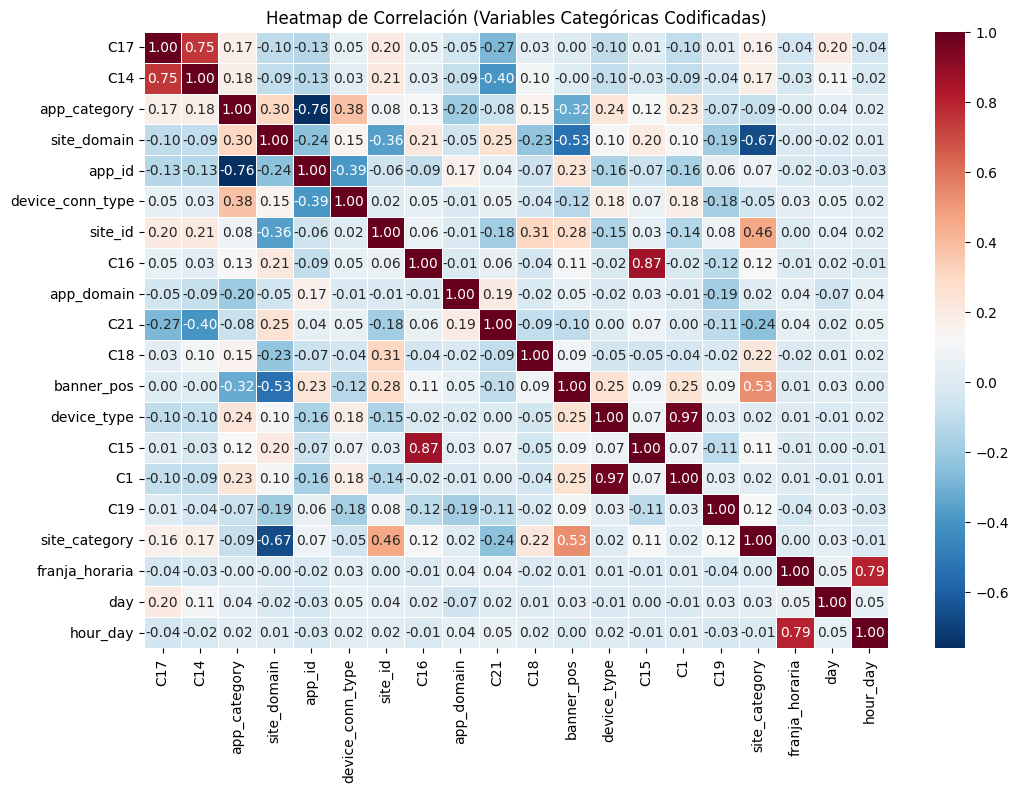

In [27]:
# Se usa la misma muestra codificada del paso anterior (df_encoded)
cols_interes = [
    'C17', 'C14', 'app_category', 'site_domain', 'app_id', 
    'device_conn_type', 'site_id', 'C16', 'app_domain', 'C21', 
    'C18', 'banner_pos', 'device_type', 'C15', 'C1', 'C19', 
    'site_category', 'franja_horaria', 'day', 'hour_day'
]

# Se calcula la correlación (Spearman es más robusta para categorías ordenadas)
corr_matrix = df_encoded[cols_interes].corr(method='spearman')


plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', fmt=".2f", linewidths=0.5)
plt.title("Heatmap de Correlación (Variables Categóricas Codificadas)")
plt.show()

Observe que existe una alta correlación entre algunas variables como: `C17`y `C14`, `franja_horaria` y `hour_day`, `app_id` y `app_category`, por lo que solo bastaría con quedarnos alguna de ellas.

Se eliminan las variables que no presentan una relación significativa con la variable objetivo, además de aquelllas variables correlacionadas, se toma una de cada par.

In [28]:
df = df.drop(columns=['year', 'month', 'app_category', 'hour_day', 'C17'])

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40428967 entries, 0 to 40428966
Data columns (total 19 columns):
 #   Column            Dtype 
---  ------            ----- 
 0   click             object
 1   C1                object
 2   banner_pos        object
 3   site_id           object
 4   site_domain       object
 5   site_category     object
 6   app_id            object
 7   app_domain        object
 8   device_model      object
 9   device_type       object
 10  device_conn_type  object
 11  C14               object
 12  C15               object
 13  C16               object
 14  C18               object
 15  C19               object
 16  C21               object
 17  day               int32 
 18  franja_horaria    object
dtypes: int32(1), object(18)
memory usage: 5.6+ GB


Fianalmente, para modelar le dataset cuenta con 19 variables y 40428967 registros.

Se convierte la variable objetivo a int por temas de modelado.

In [30]:
df['click'] = df['click'].astype(int)

Luego se crea un archivo csv, con el fin de almacenar la base de datos con todas las modificaciones hechas y evitar correr continuamente el código al momento de modelar.

In [31]:
df.to_csv("train_limpio.csv", index=False)

In [32]:
df = pd.read_csv("train_limpio.csv")

## **5. Modelado**

### **5.1. Modelado: Scikit-learn**

#### **Preprocesamiennto**

Inicialmente, se toma una muestra representativa del dataset con 1000000 de registros.

In [33]:
from sklearn.model_selection import train_test_split

todas_las_variables = [col for col in df.columns if col != 'click']

_, df_sample = train_test_split(
    df, 
    test_size=1000000 / len(df), 
    stratify=df['click'], 
    random_state=42
)

In [34]:
X_sample = df_sample[todas_las_variables]
y_sample = df_sample['click']

Se detectan los tipos de variables tanto categóricas como numéricas que se tomarán en cuenta para modelar.

In [35]:
cols_categoricas = X_sample.select_dtypes(include=['object', 'category']).columns.tolist()
cols_num = X_sample.select_dtypes(include=['number']).columns.tolist()

print(f"Categóricas para el modelo: {cols_categoricas}")
print(f"Numéricas para el modelo: {cols_num}")

Categóricas para el modelo: ['site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'device_model', 'C14', 'franja_horaria']
Numéricas para el modelo: ['C1', 'banner_pos', 'device_type', 'device_conn_type', 'C15', 'C16', 'C18', 'C19', 'C21', 'day']


Se separa la muestra con una proporciión 80/20.

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.20, stratify=y_sample, random_state=42
)

Luego,se crean los pipelines de preprocesmaiento para las variables.

In [37]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), cols_categoricas),
        ('num', StandardScaler(), cols_num)
    ])

In [38]:
pipeline_grid = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', MLPClassifier(random_state=42, early_stopping=True))
])

In [39]:
param_grid = {
    'classifier__hidden_layer_sizes': [(10,), (20,),(50)],
    'classifier__alpha': [0.1, 0.01],
    'classifier__max_iter': [100, 200]
}

In [40]:
from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score, accuracy_score
)

# --- EVALUAR MÚLTIPLES THRESHOLDS ---

def evaluar_thresholds(y_true, y_probs, thresholds=None):

    if thresholds is None:
        thresholds = np.arange(0.05, 0.55, 0.05)
    
    resultados = []

    for t in thresholds:
        y_pred_custom = (y_probs >= t).astype(int)

        tn, fp, fn, tp = confusion_matrix(y_true, y_pred_custom).ravel()

        resultados.append({
            "threshold": round(float(t), 3),
            "precision": precision_score(y_true, y_pred_custom, zero_division=0),
            "recall": recall_score(y_true, y_pred_custom, zero_division=0),
            "f1": f1_score(y_true, y_pred_custom, zero_division=0),
            "accuracy": accuracy_score(y_true, y_pred_custom),
            "tp": tp,
            "fp": fp,
            "tn": tn,
            "fn": fn
        })

    return pd.DataFrame(resultados)


# --- GRÁFICAS ---

def graficar_metricas_threshold(df_thresholds, model_name="Modelo"):
    plt.figure(figsize=(10,5))
    plt.plot(df_thresholds["threshold"], df_thresholds["f1"], marker='o', label="F1-Score", lw=2)
    plt.plot(df_thresholds["threshold"], df_thresholds["precision"], marker='s', label="Precision", alpha=0.7)
    plt.plot(df_thresholds["threshold"], df_thresholds["recall"], marker='^', label="Recall", alpha=0.7)
    plt.xlabel("Threshold (Umbral)")
    plt.ylabel("Score")
    plt.title(f"Métricas vs Threshold - {model_name}")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

def graficar_roc(y_true, y_probs, model_name="Modelo"):
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(7,5))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlabel("False Positive Rate (1 - Especificidad)")
    plt.ylabel("True Positive Rate (Sensibilidad)")
    plt.title(f"Curva ROC - {model_name}")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

def graficar_precision_recall(y_true, y_probs, model_name="Modelo"):
    precision, recall, _ = precision_recall_curve(y_true, y_probs)

    plt.figure(figsize=(7,5))
    plt.plot(recall, precision, color='green', lw=2)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Curva Precision-Recall - {model_name}")
    plt.grid(alpha=0.3)
    plt.show()

def graficar_matriz_confusion(y_true, y_probs, threshold, model_name="Modelo"):
    y_pred_custom = (y_probs >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred_custom)
    
    fig, ax = plt.subplots(figsize=(6,5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues", ax=ax)
    plt.title(f"Matriz de Confusión ({model_name})\nThreshold: {threshold}")
    plt.show()


# --- FUNCIÓN INTEGRADORA ---

def analizar_modelo_sklearn(y_true, y_probs, model_name="Modelo", thresholds=None):
    print("-" * 50)
    print(f"ANÁLISIS DE RENDIMIENTO: {model_name}")
    print("-" * 50)

    # 1. Evaluar thresholds
    df_thresholds = evaluar_thresholds(y_true, y_probs, thresholds)
    
    # 2. Hallar el mejor
    mejor_f1_idx = df_thresholds["f1"].idxmax()
    mejor_row = df_thresholds.loc[mejor_f1_idx]
    
    print(f"\nMejor Threshold según F1-Score: {mejor_row['threshold']}")
    print(mejor_row)

    graficar_metricas_threshold(df_thresholds, model_name)
    graficar_roc(y_true, y_probs, model_name)
    graficar_precision_recall(y_true, y_probs, model_name)
    graficar_matriz_confusion(y_true, y_probs, mejor_row['threshold'], model_name)

    return df_thresholds, mejor_row

Finalmente, se modela con scikit learn usando la muestra representativa y siguiendo la configuración recomendada. En este caso se trabaja con 10, 20 y 50 neuronas. Asimismo, los hiperparámetros 0.1 y 0.01 y un máximo de iteraciones de 100 y 200. Es importante aclarar que esta configuración se toma debido a la capacidad que podemos correr con PySpark y luego poder comparar ambos modelos.

In [41]:
import time
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

grid_search = GridSearchCV(
    pipeline_grid, 
    param_grid, 
    cv=3, 
    scoring='roc_auc', 
    n_jobs=-1, 
    verbose=2
)

inicio_total = time.time()
grid_search.fit(X_train, y_train)
fin_total = time.time()

print(f"\nTiempo total: {(fin_total - inicio_total)/60:.2f} minutos")
print(f"Mejores parámetros: {grid_search.best_params_}")

Fitting 3 folds for each of 12 candidates, totalling 36 fits

Tiempo total: 5.86 minutos
Mejores parámetros: {'classifier__alpha': 0.01, 'classifier__hidden_layer_sizes': 50, 'classifier__max_iter': 100}


Durante la modelación se hizo una búsqueda mediante GridSearchCV para optimizar el rendimiento de la red neuronal,  evaluando 36 combinaciones a través de una validación cruzada de tres pliegues. El modelo duró 5.95 minutos en procesar y arrojó el mejor modelo el cual coresponde de al parámetro de regularización alpha de  y una arquitectura de capa oculta con 50 neuronas con 100 iteraciones máximas.

--------------------------------------------------
ANÁLISIS DE RENDIMIENTO: Mi Bosque Aleatorio
--------------------------------------------------

Mejor Threshold según F1-Score: 0.2
threshold         0.200000
precision         0.296708
recall            0.651218
f1                0.407672
accuracy          0.678665
tp            22116.000000
fp            52422.000000
tn           113617.000000
fn            11845.000000
Name: 3, dtype: float64


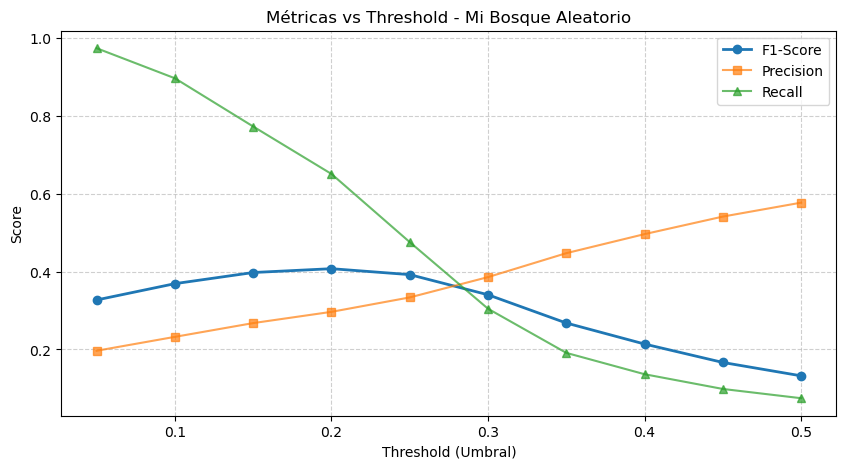

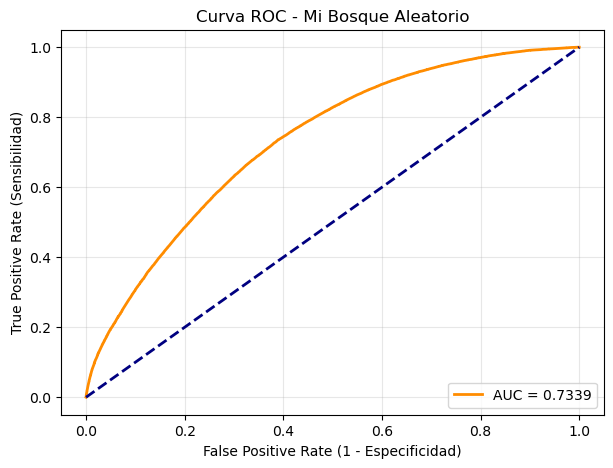

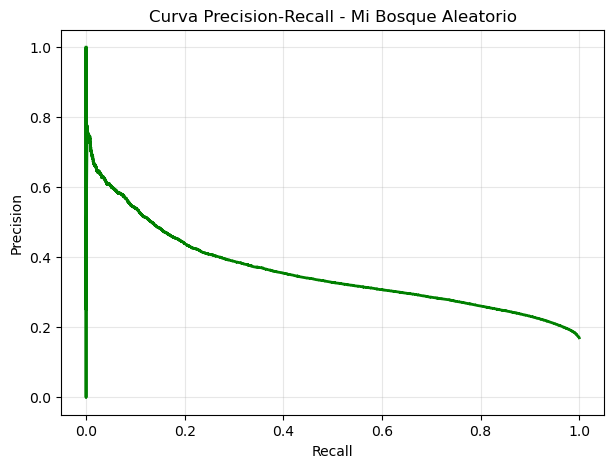

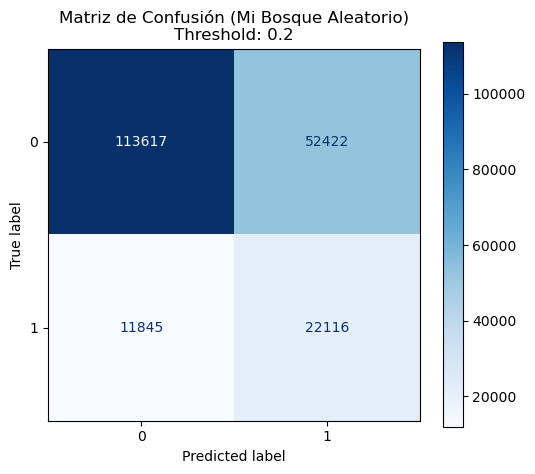

In [ ]:
import time
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, confusion_matrix, 
    ConfusionMatrixDisplay
)

best_mlp = grid_search.best_estimator_

# Medir tiempo de predicción
inicio_pred = time.time()
y_pred = best_mlp.predict(X_test)
y_proba = best_mlp.predict_proba(X_test)[:, 1]
fin_pred = time.time()

df_res, mejor_t = analizar_modelo_sklearn(y_test, y_proba, model_name="Mi Bosque Aleatorio")

Al analizar el desempeño del modelo final, se observa que la estrategia de ajustar el umbral de decisión a 0.2 fue fundamental para maximizar el F1-Score, logrando un equilibrio necesario ante el notable desbalance de las clases. Los resultados muestran que, aunque la precisión se sitúa en 0.29, el modelo consigue capturar el 65% de los clics reales (Recall), lo cual es un indicador positivo en problemas de Click-Through Rate donde interesa no perder oportunidades de interacción. La curva ROC, con un AUC de 0.7339, confirma que el sistema tiene una capacidad de discriminación sólida y muy superior a una clasificación aleatoria. Finalmente, la matriz de confusión revela que, si bien el modelo tiende a generar una cantidad considerable de falsos positivos, logra identificar correctamente a más de 22,000 usuarios que sí hicieron clic, demostrando ser una herramienta eficaz para la segmentación en este conjunto de datos masivo.

Analizando la instancia de error en el índice: 6
Predicción del modelo: 0
Valor real: 1


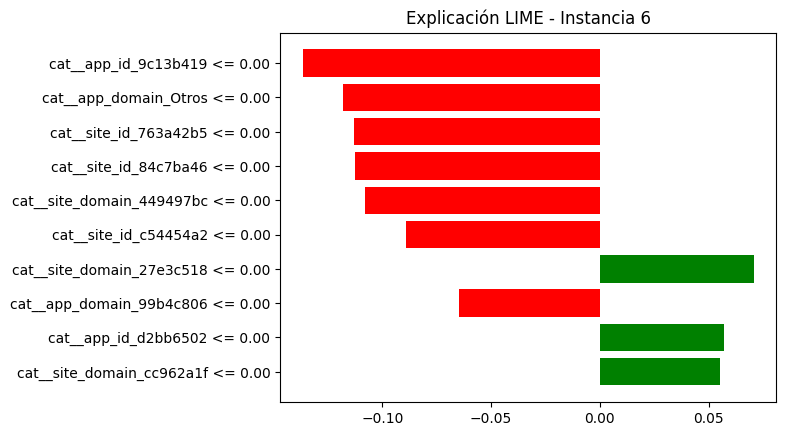

In [43]:
import lime
import lime.lime_tabular
import numpy as np


errores_idx = np.where(y_pred != y_test.values)[0]
instancia_idx = errores_idx[0] 

print(f"Analizando la instancia de error en el índice: {instancia_idx}")
print(f"Predicción del modelo: {y_pred[instancia_idx]}")
print(f"Valor real: {y_test.values[instancia_idx]}")

X_train_transformed = best_mlp.named_steps['preprocessor'].transform(X_train)
feature_names = best_mlp.named_steps['preprocessor'].get_feature_names_out()

explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_transformed.toarray(), 
    feature_names=feature_names,
    class_names=['No Click', 'Click'],
    mode='classification'
)

predict_fn = lambda x: best_mlp.named_steps['classifier'].predict_proba(x)

exp = explainer.explain_instance(
    data_row=best_mlp.named_steps['preprocessor'].transform(X_test.iloc[[instancia_idx]]).toarray()[0], 
    predict_fn=predict_fn,
    num_features=10
)

exp.show_in_notebook(show_table=True)
exp.as_pyplot_figure()
plt.title(f"Explicación LIME - Instancia {instancia_idx}")
plt.show()

Al analizar la instancia de error número 6 mediante LIME, se observa un caso de falso negativo, donde el modelo predijo erróneamente que no habría un clic (0) cuando el valor real fue positivo (1). La explicación revela que el modelo asignó una probabilidad del 85% a la clase "No Click", impulsada principalmente por la ausencia de ciertos dominios y aplicaciones específicas, representados por las barras rojas que empujan la predicción hacia la izquierda. Aunque existen un par de características (en verde) que sugieren una probabilidad de interacción, su peso es mínimo comparado con la influencia negativa de las demás variables. En última instancia, este análisis permite identificar que el modelo falló porque la combinación de atributos de este usuario se asemeja demasiado al patrón típico de quienes no interactúan, subrayando la dificultad de detectar clics en casos con características poco deterministas.

### **5.2. Modelado: PySpark**

#### **Preprocesamiento**

In [44]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split
from pyspark.sql import SparkSession
from pyspark.ml.classification import MultilayerPerceptronClassifier

In [46]:
os.environ["JAVA_HOME"] = r"C:\Program Files\Eclipse Adoptium\jdk-11.0.30.7-hotspot"
os.environ["SPARK_HOME"] = r"C:\Users\Guirlessa\miniconda3\envs\dl_venv\Lib\site-packages\pyspark"
os.environ["PATH"] += r";C:\Users\Guirlessa\miniconda3\envs\dl_venv\Scripts"
os.environ["PYSPARK_PYTHON"] = r"C:\Users\Guirlessa\miniconda3\envs\dl_venv\python.exe"
os.environ["PYSPARK_DRIVER_PYTHON"] = r"C:\Users\Guirlessa\miniconda3\envs\dl_venv\python.exe"

In [47]:
spark = SparkSession.builder \
    .appName("Avazu_CTR") \
    .config("spark.driver.memory", "16g") \
    .config("spark.executor.memory", "16g") \
    .config("spark.memory.offHeap.enabled", "true") \
    .config("spark.memory.offHeap.size", "4g") \
    .config("spark.sql.shuffle.partitions", "200") \
    .getOrCreate()

df = spark.read.csv("train_limpio.csv", header=True, inferSchema=True)

In [48]:
df.show()

+-----+----+----------+--------+-----------+-------------+--------+----------+------------+-----------+----------------+-----+---+---+---+---+---+---+--------------+
|click|  C1|banner_pos| site_id|site_domain|site_category|  app_id|app_domain|device_model|device_type|device_conn_type|  C14|C15|C16|C18|C19|C21|day|franja_horaria|
+-----+----+----------+--------+-----------+-------------+--------+----------+------------+-----------+----------------+-----+---+---+---+---+---+---+--------------+
|    0|1005|         0|1fbe01fe|   f3845767|     28905ebd|ecad2386|  7801e8d9|       Otros|          1|               2|15706|320| 50|  0| 35| 79| 21|     madrugada|
|    0|1005|         0|1fbe01fe|   f3845767|     28905ebd|ecad2386|  7801e8d9|    711ee120|          1|               0|15704|320| 50|  0| 35| 79| 21|     madrugada|
|    0|1005|         0|1fbe01fe|   f3845767|     28905ebd|ecad2386|  7801e8d9|    8a4875bd|          1|               0|15704|320| 50|  0| 35| 79| 21|     madrugada|
|   

In [49]:
print(f"Variables Categoricas para modelar:{cols_categoricas}")

Variables Categoricas para modelar:['site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'device_model', 'C14', 'franja_horaria']


In [50]:
print(f"Variables Numéricas para modelar:{cols_num}")

Variables Numéricas para modelar:['C1', 'banner_pos', 'device_type', 'device_conn_type', 'C15', 'C16', 'C18', 'C19', 'C21', 'day']


In [51]:
from pyspark.ml.feature import StringIndexer

indexers = [
    StringIndexer(inputCol=col, outputCol=col + "_idx", handleInvalid="keep")
    for col in cols_categoricas
]

In [52]:
from pyspark.ml.feature import OneHotEncoder

encoder = OneHotEncoder(
    inputCols=[col + "_idx" for col in cols_categoricas],
    outputCols=[col + "_ohe" for col in cols_categoricas]
)

In [53]:
from pyspark.ml.feature import VectorAssembler

feature_cols = [col + "_ohe" for col in cols_categoricas] + cols_num

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

In [54]:
from pyspark.ml.feature import StandardScaler

scaler = StandardScaler(
    inputCol="features",
    outputCol="scaled_features",
    withStd=True,
    withMean=False 
)

In [55]:
from pyspark.ml import Pipeline

pipeline = Pipeline(stages=indexers + [encoder, assembler, scaler])

Posteriormente, el conjunto de datos fue dividido en dos subconjuntos: entrenamiento y prueba, utilizando una proporción de 80% y 20%, respectivamente. Esta partición se realizó con el propósito de entrenar los modelos predictivos sobre la mayor parte de la información disponible y, posteriormente, evaluar su capacidad de generalización sobre datos no vistos durante el proceso de entrenamiento.

In [56]:
train_df, test_df = df.randomSplit([0.8, 0.2], seed=42)

In [57]:
model_pipeline = pipeline.fit(train_df)

train_transformed = model_pipeline.transform(train_df)
test_transformed = model_pipeline.transform(test_df)

In [58]:
train_data = train_transformed.selectExpr("scaled_features as features", "click as label")
test_data  = test_transformed.selectExpr("scaled_features as features", "click as label")

In [59]:
num_features = train_data.select("features").first()[0].size
print("Número de features:", num_features)

Número de features: 646


In [60]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.mllib.evaluation import MulticlassMetrics

evaluator = BinaryClassificationEvaluator(
    labelCol="label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
)

#### **Modelado:**

In [64]:
import time
from pyspark.ml.classification import MultilayerPerceptronClassifier
from pyspark.sql.functions import col

def run_mlp_experiment(train_data, test_data, layers, step, max_iter, evaluator, model_name="modelo"):
    
    print("\n" + "="*60)
    print(f"Configuración:")
    print(f"Modelo: {model_name}")
    print(f"Layers: {layers}")
    print(f"StepSize: {step}")
    print(f"MaxIter: {max_iter}")
    print("="*60)
    
    # 🔹 Modelo
    mlp = MultilayerPerceptronClassifier(
        featuresCol="features",
        labelCol="label",
        layers=layers,
        stepSize=step,
        maxIter=max_iter,
        seed=42
    )
    
    # 🔹 Entrenamiento
    print("Entrenando modelo...")
    start_train = time.time()
    model = mlp.fit(train_data)
    train_time = time.time() - start_train
    print(f"✔ Entrenamiento terminado en {train_time:.2f} segundos")
    
    #  Predicción
    print("Realizando predicciones...")
    start_pred = time.time()
    predictions = model.transform(test_data).cache()
    count = predictions.count()
    pred_time = time.time() - start_pred
    
    print(f"✔ Predicción terminada en {pred_time:.2f} segundos")
    print(f"Total registros evaluados: {count}")
    
    #  Evaluación
    print("Calculando métricas...")
    
    auc = evaluator.evaluate(predictions)
    
    tp = predictions.filter((col("prediction") == 1) & (col("label") == 1)).count()
    fp = predictions.filter((col("prediction") == 1) & (col("label") == 0)).count()
    tn = predictions.filter((col("prediction") == 0) & (col("label") == 0)).count()
    fn = predictions.filter((col("prediction") == 0) & (col("label") == 1)).count()

    precision = tp / (tp + fp) if (tp + fp) != 0 else 0
    recall = tp / (tp + fn) if (tp + fn) != 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

    print("\nResultados:")
    print(f"AUC: {auc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}")
    
    print("\nMatriz de confusión:")
    print(f"TP: {tp} | FP: {fp}")
    print(f"FN: {fn} | TN: {tn}")
    
    #  Resumen del modelo
    result = {
        "model_name": model_name,
        "layers": str(layers),
        "stepSize": step,
        "maxIter": max_iter,
        "AUC": auc,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "TP": tp,
        "FP": fp,
        "TN": tn,
        "FN": fn,
        "Train_Time": train_time,
        "Pred_Time": pred_time
    }
    
    return model, predictions, result

##### **MLP_10_0.01_100**

In [65]:
model_1, preds_1, result_1 = run_mlp_experiment(
    train_data,
    test_data,
    layers=[num_features, 10, 2],
    step=0.01,
    max_iter=100,
    evaluator=evaluator,
    model_name="MLP_10_0.01_100"
)


Configuración:
Modelo: MLP_10_0.01_100
Layers: [646, 10, 2]
StepSize: 0.01
MaxIter: 100
Entrenando modelo...
✔ Entrenamiento terminado en 5247.81 segundos
Realizando predicciones...
✔ Predicción terminada en 47.71 segundos
Total registros evaluados: 8087248
Calculando métricas...

Resultados:
AUC: 0.7083
Precision: 0.0000
Recall: 0.0000
F1-score: 0.0000

Matriz de confusión:
TP: 0 | FP: 6
FN: 1374528 | TN: 6712714


**Análisis Preeliminar:**

Se entrenó un modelo de red neuronal tipo Perceptrón Multicapa (MLP) con arquitectura **[646, 10, 2]**, una tasa de aprendizaje (step size) de 0.01 y un máximo de 100 iteraciones.

El tiempo de entrenamiento fue de *5247.81 segundos*, mientras que la fase de predicción sobre el conjunto de prueba requirió *47.71 segundos*, evaluándose un total de *8,087,248 registros*.

**Desempeño General:**

El modelo obtuvo un valor de **AUC = 0.7083**, lo cual indica que el modelo tiene una capacidad discriminativa moderada, es decir, tiene cierta habilidad para diferenciar entre las observaciones de la clase positiva (`click = 1`) y la clase negativa (`Click = 0`).

En terminos practivos, el AUC obtenido nos sugiere que el modelo logra capturar patrones relevantes, dado que su desempeño es superior al azar. Sin embargo, las métricas de clasificación nos reportan otro panorama:

- Precision = 0.000
- Recall = 0.0000
- F1-Score = 0.000

Estos resultados nos indican un desempeño nulo sobre la clase positiva. Sin embargo, esto no implica necesariamente que el modelo no haya aprendido, sino que el umbral de decisión utilizado por defecto fue inadecuado para este problema.

##### **MLP_20_0.01_100**

In [72]:
model_2, preds_2, result_2 = run_mlp_experiment(
    train_data,
    test_data,
    layers=[num_features, 20, 2],
    step=0.01,
    max_iter=100,
    evaluator=evaluator,
    model_name="MLP_20_0.01_100")


Configuración:
Modelo: MLP_20_0.01_100
Layers: [646, 20, 2]
StepSize: 0.01
MaxIter: 100
Entrenando modelo...
✔ Entrenamiento terminado en 12927.86 segundos
Realizando predicciones...
✔ Predicción terminada en 52.83 segundos
Total registros evaluados: 8087248
Calculando métricas...

Resultados:
AUC: 0.7102
Precision: 0.0000
Recall: 0.0000
F1-score: 0.0000

Matriz de confusión:
TP: 0 | FP: 0
FN: 1374528 | TN: 6712720


**Análisis Preeliminar:**

En segunda instancia, se entrenó un modelo de red neuronal tipo Perceptrón Multicapa (MLP) con arquitectura **[646, 20, 2]**, una tasa de aprendizaje (step size) de 0.01 y un máximo de 100 iteraciones.

El tiempo de entrenamiento fue de *12927.86 segundos*, mientras que la fase de predicción sobre el conjunto de prueba requirió *52.83 segundos*, evaluándose un total de *8,087,248 registros*.

**Desempeño General:**

El modelo obtuvo un valor de **AUC = 0.7102**,lo que representa un desempeño ligeramente superior al observado en el modelo anterior. Este resultado sugiere una capacidad discriminativa moderada, es decir, una habilidad aceptable para diferenciar entre observaciones pertenecientes a la clase positiva y la clase negativa. No obstante, al analizar las métricas de clasificación asociadas a la clase positiva, se obtuvieron nuevamente resultados nulos:

- Precision = 0.000
- Recall = 0.0000
- F1-Score = 0.000

Por tanto, resulta pertinente evaluar distintos valores de threshold con el fin de determinar si un ajuste en el umbral de decisión permite mejorar el desempeño del modelo, particularmente en términos de precision, recall y F1-score, tanto para este modelo como para el anterior.

##### **MLP_50_0.01_100**

In [75]:
model_3, preds_3, result_3 = run_mlp_experiment(
    train_data,
    test_data,
    layers=[num_features, 50, 2],
    step=0.01,
    max_iter=100,
    evaluator=evaluator,
    model_name="MLP_50_0.01_100")


Configuración:
Modelo: MLP_50_0.01_100
Layers: [646, 50, 2]
StepSize: 0.01
MaxIter: 100
Entrenando modelo...
✔ Entrenamiento terminado en 13539.28 segundos
Realizando predicciones...
✔ Predicción terminada en 56.96 segundos
Total registros evaluados: 8087248
Calculando métricas...

Resultados:
AUC: 0.7199
Precision: 0.0000
Recall: 0.0000
F1-score: 0.0000

Matriz de confusión:
TP: 0 | FP: 5
FN: 1374528 | TN: 6712715


**Análisis preliminar**

Como tercera configuración experimental, se entrenó un modelo de red neuronal tipo Perceptrón Multicapa (MLP) con arquitectura **[646, 50, 2]**, una tasa de aprendizaje (step size) de 0.01 y un máximo de 100 iteraciones.

El proceso de entrenamiento tuvo una duración de *13,539.28 segundos*, mientras que la fase de predicción sobre el conjunto de prueba requirió *56.96 segundos*. En total, se evaluaron *8,087,248 registros*.

**Desempeño general**

El modelo obtuvo un valor de **AUC = 0.7199**, lo que representa el mejor desempeño discriminativo entre las configuraciones MLP evaluadas hasta este punto. Este resultado sugiere una capacidad moderada de separación entre clases, indicando que el modelo logra capturar patrones relevantes en los datos y distinguir en cierta medida entre observaciones de la clase positiva y negativa.

No obstante, al analizar las métricas de clasificación asociadas a la clase positiva, se observó nuevamente un comportamiento nulo:

- Precision = 0.0000
- Recall = 0.0000
- F1-score = 0.0000

Estos resultados evidencian que, bajo el umbral de decisión utilizado, el modelo no logró identificar correctamente ningún caso perteneciente a la clase positiva.

La matriz de confusión confirmó este comportamiento, al mostrar:

Verdaderos Positivos (TP): 0
Falsos Positivos (FP): 5
Falsos Negativos (FN): 1,374,528
Verdaderos Negativos (TN): 6,712,715

Esto indica que el modelo clasificó prácticamente la totalidad de las observaciones como pertenecientes a la clase negativa (0), reproduciendo un patrón altamente sesgado hacia la clase mayoritaria.

In [76]:
import pandas as pd

results_df = pd.DataFrame([result_1, result_2, result_3])
results_df.to_csv("resultados_mlp_avazu.csv", index=False)

print("Resultados guardados en resultados_mlp_avazu.csv")

Resultados guardados en resultados_mlp_avazu.csv


In [77]:
results = []
all_predictions = {}

results.append(result_1)
all_predictions["MLP_10_0.01_100"] = preds_1

In [78]:
results.append(result_2)
all_predictions["MLP_20_0.01_100"] = preds_2

results.append(result_3)
all_predictions["MLP_50_0.01_100"] = preds_3

#### **Evaluando los Modelos:**

##### **Función:**

In [67]:

#EVALUACIÓN POR THRESHOLD

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from pyspark.sql.functions import col, udf
from pyspark.sql.types import DoubleType

from sklearn.metrics import (
    roc_curve, auc,
    precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

# EXTRAER PROBABILIDAD DE CLASE POSITIVA


extract_prob_1 = udf(lambda v: float(v[1]), DoubleType())

def preparar_predicciones(preds_spark):
    """
    Agrega columna prob_1 = probabilidad de clase positiva.
    """
    preds_prob = preds_spark.withColumn("prob_1", extract_prob_1(col("probability")))
    return preds_prob


# EVALUAR MÚLTIPLES THRESHOLDS

def evaluar_thresholds(preds_prob, thresholds=None):

    if thresholds is None:
        thresholds = np.arange(0.05, 0.55, 0.05)  # 0.05 a 0.50
    
    resultados = []

    for t in thresholds:
        pred_t = preds_prob.withColumn(
            "pred_custom",
            (col("prob_1") >= float(t)).cast("double")
        )

        tp = pred_t.filter((col("pred_custom") == 1) & (col("label") == 1)).count()
        fp = pred_t.filter((col("pred_custom") == 1) & (col("label") == 0)).count()
        tn = pred_t.filter((col("pred_custom") == 0) & (col("label") == 0)).count()
        fn = pred_t.filter((col("pred_custom") == 0) & (col("label") == 1)).count()

        precision = tp / (tp + fp) if (tp + fp) != 0 else 0
        recall = tp / (tp + fn) if (tp + fn) != 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0
        accuracy = (tp + tn) / (tp + tn + fp + fn)

        resultados.append({
            "threshold": round(float(t), 3),
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "accuracy": accuracy,
            "tp": tp,
            "fp": fp,
            "tn": tn,
            "fn": fn
        })

    df_thresholds = pd.DataFrame(resultados)
    return df_thresholds


# GRAFICAS MÉTRICAS VS THRESHOLD

def graficar_metricas_threshold(df_thresholds, model_name="Modelo"):
    """
    Grafica F1, Precision y Recall vs threshold.
    """
    plt.figure(figsize=(10,6))
    plt.plot(df_thresholds["threshold"], df_thresholds["f1"], marker='o', label="F1")
    plt.plot(df_thresholds["threshold"], df_thresholds["precision"], marker='o', label="Precision")
    plt.plot(df_thresholds["threshold"], df_thresholds["recall"], marker='o', label="Recall")
    plt.xlabel("Threshold")
    plt.ylabel("Valor")
    plt.title(f"Métricas vs Threshold - {model_name}")
    plt.legend()
    plt.grid(True)
    plt.show()


# MEJOR THRESHOLD SEGÚN F1

def obtener_mejor_threshold(df_thresholds):
    """
    Devuelve la fila con el mejor threshold según F1.
    """
    mejor = df_thresholds.loc[df_thresholds["f1"].idxmax()]
    return mejor


# MATRIZ DE CONFUSIÓN PARA UN THRESHOLD DADO

def graficar_matriz_confusion(preds_prob, threshold, model_name="Modelo", sample_frac=0.1):
    """
    Grafica la matriz de confusión usando un threshold personalizado.
    Se usa muestra para no explotar memoria.
    """
    pred_t = preds_prob.withColumn(
        "pred_custom",
        (col("prob_1") >= float(threshold)).cast("double")
    )

    pdf = pred_t.select("label", "pred_custom").sample(fraction=sample_frac, seed=42).toPandas()

    cm = confusion_matrix(pdf["label"], pdf["pred_custom"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(f"Matriz de Confusión - {model_name} (threshold={threshold})")
    plt.show()


# CURVA ROC


def graficar_roc(preds_prob, model_name="Modelo", sample_frac=0.1):
    """
    Grafica la curva ROC usando muestra.
    """
    pdf = preds_prob.select("label", "prob_1").sample(fraction=sample_frac, seed=42).toPandas()

    fpr, tpr, _ = roc_curve(pdf["label"], pdf["prob_1"])
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(8,6))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0,1], [0,1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"Curva ROC - {model_name}")
    plt.legend()
    plt.grid(True)
    plt.show()


# CURVA PRECISION-RECALL

def graficar_precision_recall(preds_prob, model_name="Modelo", sample_frac=0.1):
    """
    Grafica la curva Precision-Recall usando muestra.
    """
    pdf = preds_prob.select("label", "prob_1").sample(fraction=sample_frac, seed=42).toPandas()

    precision, recall, _ = precision_recall_curve(pdf["label"], pdf["prob_1"])

    plt.figure(figsize=(8,6))
    plt.plot(recall, precision)
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"Curva Precision-Recall - {model_name}")
    plt.grid(True)
    plt.show()


def analizar_modelo(preds_spark, model_name="Modelo", thresholds=None, sample_frac=0.1):

    print("="*70)
    print(f"ANÁLISIS DEL MODELO: {model_name}")
    print("="*70)

    preds_prob = preparar_predicciones(preds_spark)

    # tabla thresholds
    df_thresholds = evaluar_thresholds(preds_prob, thresholds)
    print("\nTabla de thresholds:")
    display(df_thresholds)

    # mejor threshold
    mejor = obtener_mejor_threshold(df_thresholds)
    print("\nMejor threshold según F1:")
    print(mejor)

    # gráficos
    graficar_metricas_threshold(df_thresholds, model_name=model_name)
    graficar_roc(preds_prob, model_name=model_name, sample_frac=sample_frac)
    graficar_precision_recall(preds_prob, model_name=model_name, sample_frac=sample_frac)
    graficar_matriz_confusion(preds_prob, threshold=mejor["threshold"], model_name=model_name, sample_frac=sample_frac)

    return preds_prob, df_thresholds, mejor

##### **MLP_10_0.01_100:**

Se evaluó el desempeño del modelo Perceptrón Multicapa (MLP) con arquitectura [646, 10, 2], tasa de aprendizaje (step size) de 0.01 y un máximo de 100 iteraciones, utilizando distintas métricas de clasificación y curvas de desempeño.

Dado el desbalance de clases presente en la variable objetivo Click, la evaluación no se limitó a la exactitud (accuracy), sino que se complementó con métricas como precision, recall, F1-score, AUC-ROC y la curva Precision-Recall, con el fin de obtener una valoración más adecuada del comportamiento del modelo frente a la clase positiva.

ANÁLISIS DEL MODELO: MLP_10_0.01_100

Tabla de thresholds:


,threshold,precision,recall,f1,accuracy,tp,fp,tn,fn
0,0.05,0.169962,1.000000,0.290543,0.169962,1374528,6712720,0,0
1,0.10,0.239250,0.823024,0.370730,0.525130,1131270,3597130,3115590,243258
2,0.15,0.271053,0.707110,0.391886,0.627013,971942,2613854,4098866,402586
3,0.20,0.290428,0.623113,0.396194,0.677195,856486,2092559,4620161,518042
4,0.25,0.312721,0.513061,0.388589,0.725593,705217,1549886,5162834,669311
5,0.30,0.334004,0.402517,0.365074,0.762037,553271,1103209,5609511,821257
6,0.35,0.403257,0.185664,0.254263,0.814897,255201,377648,6335072,1119327
7,0.40,0.000000,0.000000,0.000000,0.830037,0,6,6712714,1374528
8,0.45,0.000000,0.000000,0.000000,0.830037,0,6,6712714,1374528
9,0.50,0.000000,0.000000,0.000000,0.830037,0,6,6712714,1374528



Mejor threshold según F1:
threshold    2.000000e-01
precision    2.904283e-01
recall       6.231128e-01
f1           3.961936e-01
accuracy     6.771954e-01
tp           8.564860e+05
fp           2.092559e+06
tn           4.620161e+06
fn           5.180420e+05
Name: 3, dtype: float64


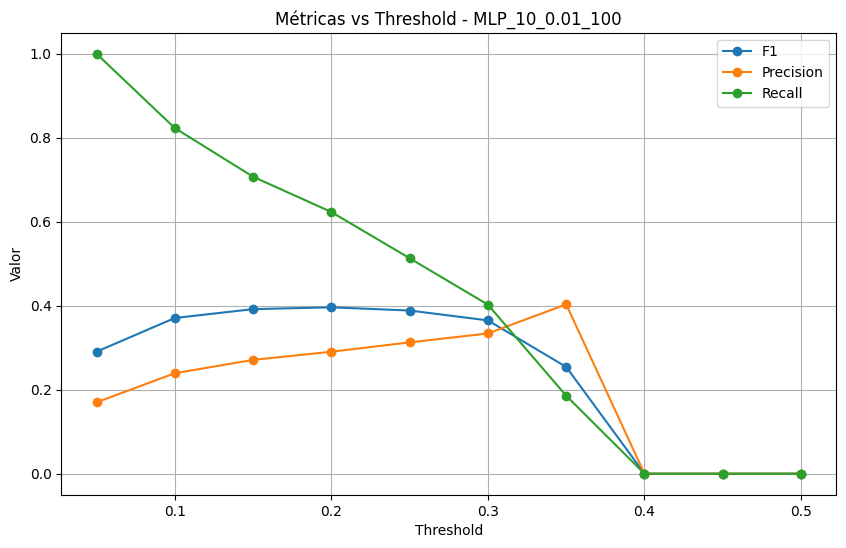

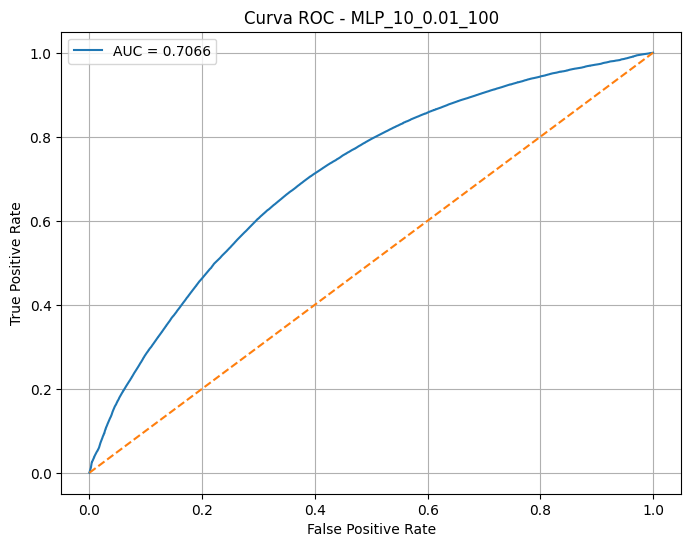

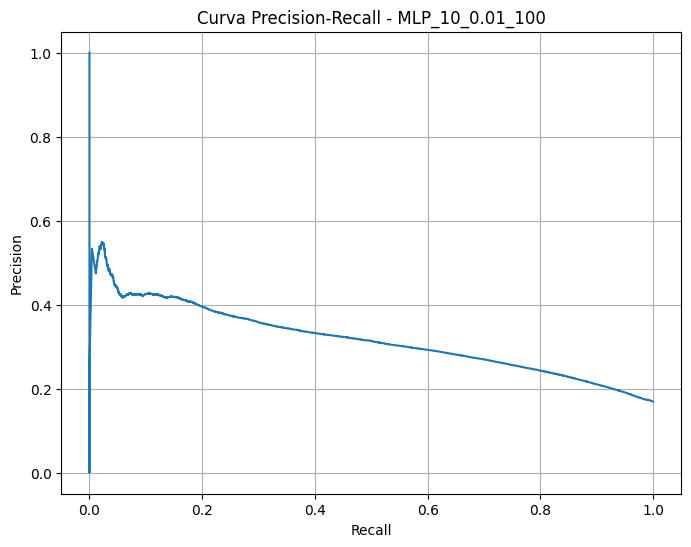

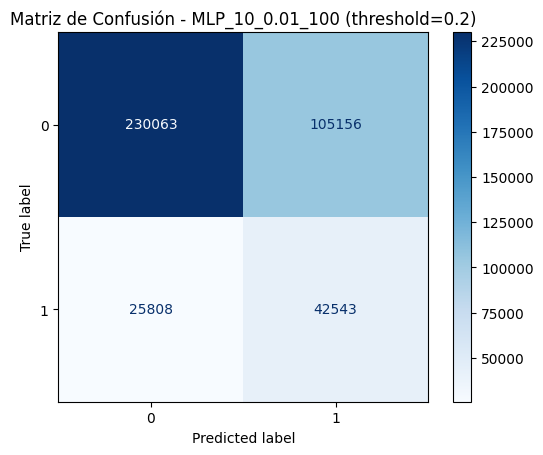

In [68]:
preds_1_prob, df_thresh_1, mejor_thresh_1 = analizar_modelo(
    preds_1,
    model_name="MLP_10_0.01_100",
    thresholds=np.arange(0.05, 0.55, 0.05),
    sample_frac=0.05   # usa 5% para no saturar RAM
)

**Análisis del Threshold de Clasificación**

En el análisis preliminar se observó que el modelo presentó un rendimiento moderado, alcanzando un valor de **AUC = 0.7083**. No obstante, las métricas Precision, Recall y F1-score arrojaron valores nulos, lo que evidenció una incapacidad del modelo para identificar adecuadamente la clase positiva bajo el umbral de decisión inicialmente utilizado. En respuesta a este comportamiento, se llevó a cabo un análisis adicional con el propósito de optimizar el desempeño del modelo sobre la clase positiva, evaluando distintos valores de threshold en un rango comprendido entre 0.05 y 0.50.

Los resultados evidenciaron que el desempeño del modelo varía de forma importante según el umbral utilizado, especialmente en términos de precision, recall y F1-score.

**Comportamiento observado:**

- **Thresholds bajos (ej. 0.05 y 0.10):** favorecen un recall alto, permitiendo detectar una mayor cantidad de casos positivos, aunque con una menor precisión.
- **Thresholds intermedios (0.15 a 0.30):** ofrecen un mejor equilibrio entre la identificación de positivos y la reducción de falsos positivos.
- **Thresholds altos (0.40, 0.45 y 0.50):** hacen que el modelo se vuelva excesivamente conservador, al punto de no identificar correctamente ningún caso positivo, obteniendo valores nulos en precision, recall y F1-score.

Este comportamiento confirma que el umbral de decisión por defecto no era adecuado para este problema, ya que impedía que el modelo explotara su capacidad predictiva sobre la clase minoritaria.

**Selección del Mejor Threshold**

Para la selección del umbral óptimo se utilizó como criterio principal el F1-score, debido a que esta métrica representa el equilibrio entre precision y recall, lo cual resulta especialmente pertinente en contextos de clasificación desbalanceada.

El mejor desempeño se obtuvo con un valor de **Threshold=0.20**. Con este umbral, el modelo alcanzó las siguientes métricas:

- Precision: 0.2904
- Recall: 0.6231
- F1-score: 0.3962
- Accuracy: 0.6772

Estos resultados indican que, al utilizar un umbral de 0.20, el modelo logra identificar aproximadamente el 62.31% de los casos positivos reales, aunque con una precisión moderada del 29.04%.

**Matriz de Confusion:**

La matriz de confusión obtenida con el threshold = 0.20 evidenció una mejora importante en la capacidad del modelo para identificar la clase positiva, al lograr 856,486 verdaderos positivos. Sin embargo, este aumento en la detección estuvo acompañado por un número considerable de falsos positivos (2,092,559), lo que explica la precisión moderada alcanzada. Asimismo, el modelo dejó sin identificar 518,042 casos positivos reales, reflejando que aún persisten errores relevantes en la clasificación. En conjunto, estos resultados muestran que, bajo este umbral, el modelo adopta un comportamiento más equilibrado entre la detección de la clase positiva y el mantenimiento de un desempeño general aceptable, aunque todavía con margen de mejora en términos de precisión y sensibilidad.

**Conclusión General**

En términos globales, el modelo MLP_10_0.01_100 mostró una capacidad moderada de discriminación con un AUC = 0.7066 (con la selección del threshold) y un desempeño sensible al umbral de clasificación utilizado.

El análisis permitió evidenciar que el uso del threshold por defecto no era adecuado para la detección de la clase positiva, ya que conducía a una clasificación excesivamente conservadora. En contraste, el ajuste del umbral a 0.20 permitió mejorar significativamente la identificación de casos positivos, alcanzando el mejor equilibrio entre precision y recall, con un F1-score de 0.3962.

##### **MLP_20_0.01_100:**

ANÁLISIS DEL MODELO: MLP_20_0.01_100

Tabla de thresholds:


,threshold,precision,recall,f1,accuracy,tp,fp,tn,fn
0,0.05,0.201214,0.954003,0.332334,0.348497,1311304,5205646,1507074,63224
1,0.10,0.218616,0.906892,0.352305,0.433252,1246549,4455450,2257270,127979
2,0.15,0.238517,0.823236,0.369871,0.523256,1131561,3612582,3100138,242967
3,0.20,0.300252,0.507367,0.377252,0.715301,697390,1625295,5087425,677138
4,0.25,0.346365,0.356647,0.351431,0.776263,490221,925109,5787611,884307
5,0.30,0.373812,0.277651,0.318634,0.798178,381639,639299,6073421,992889
6,0.35,0.416714,0.193813,0.264573,0.816870,266401,372889,6339831,1108127
7,0.40,0.462763,0.140645,0.215725,0.826191,193320,224432,6488288,1181208
8,0.45,0.482675,0.127812,0.202106,0.828478,175681,188293,6524427,1198847
9,0.50,0.000000,0.000000,0.000000,0.830038,0,0,6712720,1374528



Mejor threshold según F1:
threshold    2.000000e-01
precision    3.002516e-01
recall       5.073669e-01
f1           3.772517e-01
accuracy     7.153008e-01
tp           6.973900e+05
fp           1.625295e+06
tn           5.087425e+06
fn           6.771380e+05
Name: 3, dtype: float64


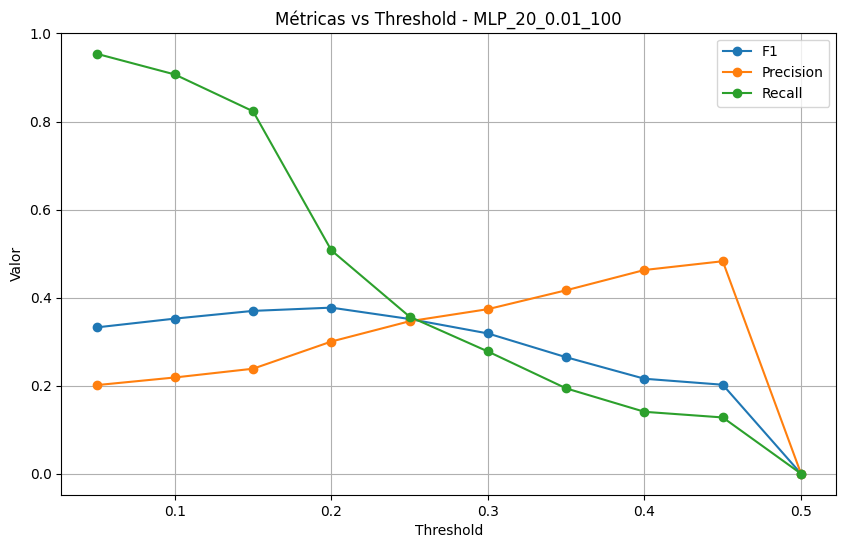

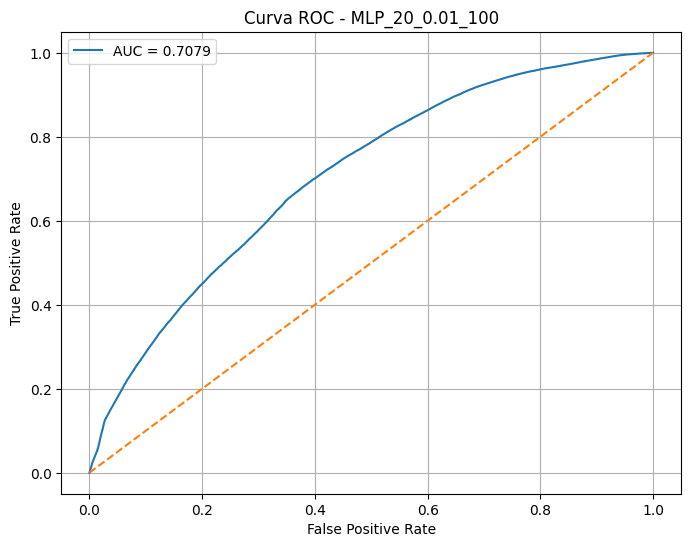

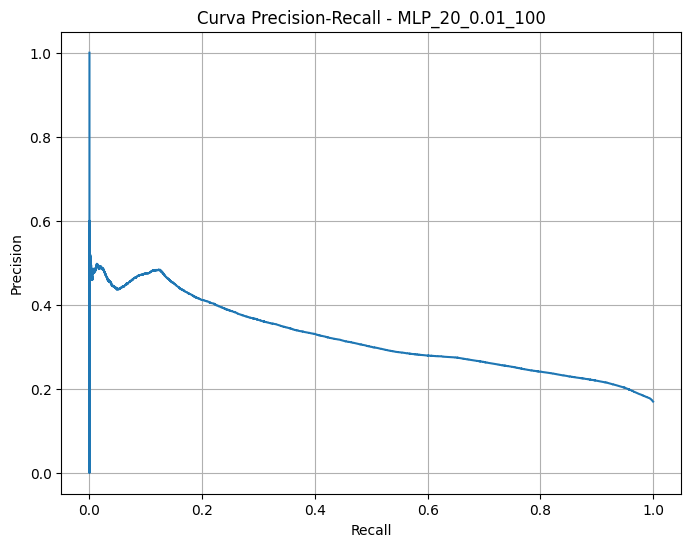

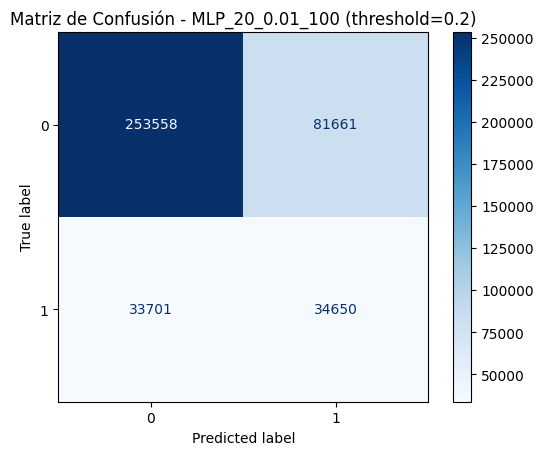

In [73]:
preds_2_prob, df_thresh_2, mejor_thresh_2 = analizar_modelo(
    preds_2,
    model_name="MLP_20_0.01_100",
    thresholds=np.arange(0.05, 0.55, 0.05),
    sample_frac=0.05   # usa 5% para no saturar RAM
)

**Análisis del Threshold de Clasificación**

En el análisis preliminar se observó que el modelo presentó un rendimiento moderado, alcanzando un valor de **AUC = 0.7102** (ligeramente superior al 0.7083 de la plantilla). Inicialmente, bajo el umbral por defecto (0.50), las métricas Precision, Recall y F1-score resultaron en valores nulos, lo que evidenció una incapacidad del modelo para identificar la clase positiva. Para corregir esto, se evaluó el desempeño en un rango de thresholds de 0.05 a 0.50.

Los resultados reafirman que el comportamiento del modelo es altamente sensible al umbral seleccionado:

**Comportamiento observado:**

* **Thresholds bajos (0.05 y 0.10):** Favorecen un **Recall** masivo (0.9540 y 0.9068 respectivamente). Aunque detectan casi todos los casos positivos reales, la precisión es baja (~20-21%), generando un volumen excesivo de falsos positivos.
* **Thresholds intermedios (0.15 a 0.30):** En este rango, el F1-score alcanza su punto máximo. A diferencia de la plantilla de referencia, este modelo muestra una caída más pronunciada del recall al pasar de 0.15 (0.8232) a 0.20 (0.5074).
* **Thresholds altos (0.40 a 0.50):** El modelo se vuelve excesivamente conservador. A partir de 0.50, la precisión y el recall caen a cero, confirmando que el modelo no asigna probabilidades altas a la clase positiva bajo la configuración actual.

**Selección del Mejor Threshold**

Para la selección del umbral óptimo se utilizó como criterio principal el **F1-score**, buscando el mejor equilibrio entre precision y recall en un contexto desbalanceado.

El mejor desempeño (al igual que en el modelo anterior) se obtuvo con un valor de **Threshold = 0.20**. A continuación, se presenta la comparativa entre los resultados obtenidos y los valores de la plantilla de referencia:

| Métrica | Modelo Actual (T=0.20) | Modelo MLP_10_0.01_100 | Diferencia |
| :--- | :--- | :--- | :--- |
| **Precision** | **0.3003** | 0.2904 | +0.0099 (Mejor) |
| **Recall** | **0.5074** | 0.6231 | -0.1157 (Peor) |
| **F1-score** | **0.3773** | 0.3962 | -0.0189 (Peor) |
| **Accuracy** | **0.7153** | 0.6772 | +0.0381 (Mejor) |

El modelo actual es ligeramente **más preciso** que el modelo anterior, pero considerablemente **menos sensible** (menor Recall). Esto resulta en un F1-score global un poco más bajo, pero con una mayor exactitud general (**Accuracy**).

**Matriz de Confusión (Threshold = 0.20)**

La matriz de confusión para el umbral óptimo revela el impacto real de la clasificación en comparación con MLP_10_0.01_100:

* **Verdaderos Positivos (TP):** 697,390 (Frente a los 856,486 del modelo anterior).
* **Falsos Positivos (FP):** 1,625,295 (Significativamente menor que los 2,092,559 del modelo anterior).
* **Falsos Negativos (FN):** 677,138 (Mayor a los 518,042 del modelo anterior).

Bajo este umbral, el modelo adopta un comportamiento **más selectivo**: sacrifica la detección de algunos positivos (aumentando los FN) para evitar generar una cantidad masiva de falsas alarmas (reduciendo los FP). Esto explica por qué el Accuracy es superior al del MLP_10_0.01_100.


**Conclusión General**

En términos globales, el modelo **MLP_20_0.01_100** mostró una capacidad de discriminación moderada con un **AUC = 0.7079**. 

El análisis permitió evidenciar que el uso del threshold por defecto no era adecuado. El ajuste del umbral a **0.20** permitió alcanzar el mejor equilibrio posible para este modelo con un **F1-score de 0.3773**. Aunque este valor es ligeramente inferior al del MLP_10_0.01_100 (0.3962), el modelo actual destaca por ser más "limpio" en sus predicciones positivas, reduciendo el ruido de los falsos positivos a costa de una menor sensibilidad.

##### **MLP_50_0.01_100:**

ANÁLISIS DEL MODELO: MLP_50_0.01_100

Tabla de thresholds:


,threshold,precision,recall,f1,accuracy,tp,fp,tn,fn
0,0.05,0.169969,0.999987,0.290553,0.170012,1374510,6712302,418,18
1,0.10,0.238388,0.857109,0.373026,0.510301,1178120,3763908,2948812,196408
2,0.15,0.261549,0.768291,0.390247,0.591940,1056038,2981590,3731130,318490
3,0.20,0.283889,0.669701,0.398747,0.656739,920523,2322028,4390692,454005
4,0.25,0.305794,0.556984,0.394823,0.709795,765590,1738025,4974695,608938
5,0.30,0.332119,0.415041,0.368979,0.758723,570486,1147228,5565492,804042
6,0.35,0.000000,0.000000,0.000000,0.830037,0,5,6712715,1374528
7,0.40,0.000000,0.000000,0.000000,0.830037,0,5,6712715,1374528
8,0.45,0.000000,0.000000,0.000000,0.830037,0,5,6712715,1374528
9,0.50,0.000000,0.000000,0.000000,0.830037,0,5,6712715,1374528



Mejor threshold según F1:
threshold    2.000000e-01
precision    2.838885e-01
recall       6.697012e-01
f1           3.987469e-01
accuracy     6.567395e-01
tp           9.205230e+05
fp           2.322028e+06
tn           4.390692e+06
fn           4.540050e+05
Name: 3, dtype: float64


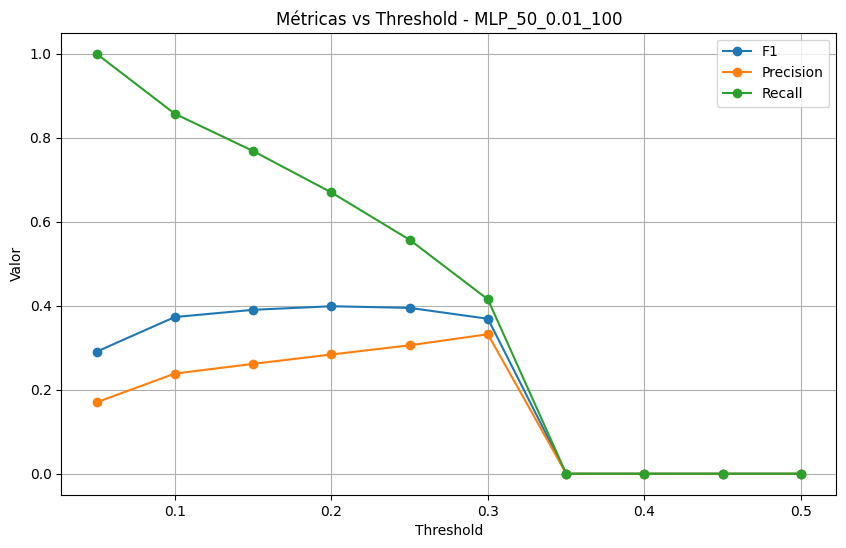

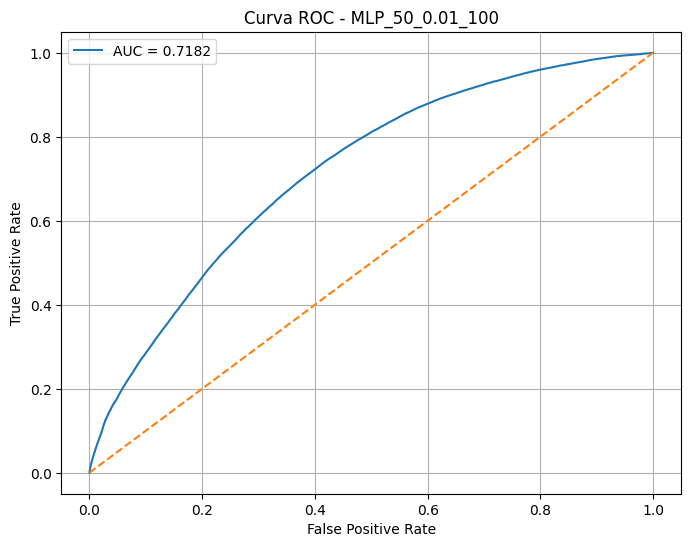

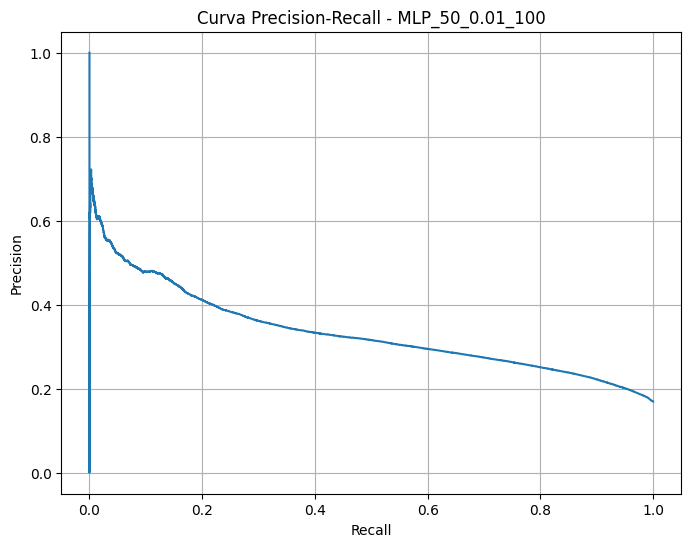

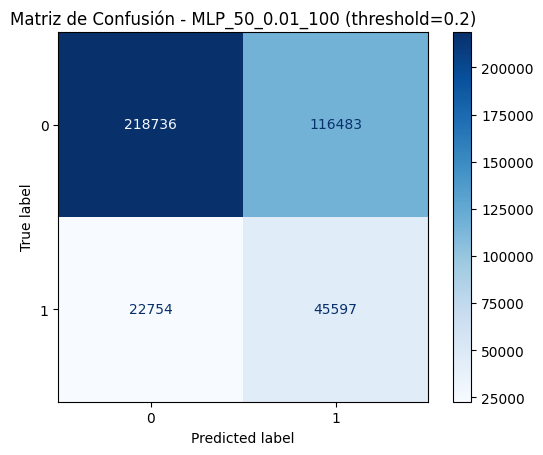

In [79]:
preds_3_prob, df_thresh_3, mejor_thresh_3 = analizar_modelo(
    preds_3,
    model_name="MLP_50_0.01_100",
    thresholds=np.arange(0.05, 0.55, 0.05),
    sample_frac=0.05   # usa 5% para no saturar RAM
)

**Análisis del Threshold de Clasificación**

En este análisis se observa que el modelo **MLP_50_0.01_100** presenta el rendimiento de discriminación más robusto hasta la fecha, alcanzando un **AUC = 0.7182**. Este valor supera tanto al modelo de la plantilla (**0.7083**) como al **MLP_20 (0.7079)**, lo que sugiere que el incremento en la complejidad de la capa oculta ha permitido capturar patrones más complejos en los datos.

Al igual que en los casos anteriores, el umbral por defecto (0.50) resultó ineficaz, arrojando métricas nulas. Por ello, se exploró el rango de 0.05 a 0.50 para identificar el punto operativo óptimo.

**Comportamiento observado:**

La matriz de confusión bajo este umbral refleja una estrategia de clasificación más audaz en comparación con los modelos previos:

* **Thresholds bajos (0.05 a 0.10):** El modelo muestra un **Recall** extremadamente agresivo, alcanzando casi el **100% (0.9999)** en el umbral 0.05. Esta sensibilidad es superior a la de los modelos previos, aunque satura el sistema con un volumen masivo de falsos positivos (precisión de solo 16.9%).
* **Thresholds intermedios (0.15 a 0.25):** El modelo sostiene el equilibrio de forma más estable que sus predecesores. Mientras que en el modelo **MLP_20** el recall caía bruscamente al llegar a 0.20, el **MLP_50** logra mantener una sensibilidad mucho más alta (**0.6697**) en el mismo punto.
* **Thresholds altos (0.35 a 0.50):** Se observa una caída crítica de rendimiento. A diferencia del **MLP_20**, que aún identificaba casos positivos en 0.45, este modelo se vuelve completamente nulo a partir del umbral 0.35, indicando que sus predicciones probabilísticas están más concentradas en rangos bajos.

**Selección del Mejor Threshold**

Siguiendo el criterio del **F1-score**, el valor óptimo se identifica nuevamente en **Threshold = 0.20**. A continuación, se presenta la comparativa trilateral:

| Métrica | MLP_50 (Actual) | MLP_20 | MLP_10_0.01_100 |
| :--- | :--- | :--- | :--- |
| **AUC** | **0.7182** | 0.7079 | 0.7083 |
| **Precision** | **0.2839** | 0.3003 | 0.2904 |
| **Recall** | **0.6697** | 0.5074 | 0.6231 |
| **F1-score** | **0.3987** | 0.3773 | 0.3962 |
| **Accuracy** | **0.6567** | 0.7153 | 0.6772 |

**Interpretación:** El **MLP_50** es el modelo con **mayor capacidad de recuperación (Recall)** de los tres. Supera por más de 4 puntos porcentuales al modelo de la plantilla y por 16 puntos al **MLP_20**. No obstante, presenta la **precisión más baja** de la comparativa, lo que indica una mayor tendencia a generar falsas alarmas.


 **Matriz de Confusión (Threshold = 0.20)**

La matriz de confusión bajo este umbral refleja una estrategia de clasificación más audaz en comparación con los modelos previos:

* **Verdaderos Positivos (TP):** 920,523 (El valor más alto registrado, superando los 856k de la plantilla y los 697k del MLP_20).
* **Falsos Positivos (FP):** 2,322,028 (Cifra significativamente superior a los modelos previos, explicando la menor precisión).
* **Falsos Negativos (FN):** 454,005 (Es el modelo que menos casos positivos reales "pierde").

En resumen, el **MLP_50** prefiere maximizar la detección de la clase positiva (sensibilidad) aceptando un incremento notable en el error de tipo I (falsos positivos).

**Conclusión General**

El modelo **MLP_50_0.01_100** se posiciona como el más efectivo en términos de capacidad discriminativa global (**AUC 0.7182**) y equilibrio de métricas combinadas (**F1 0.3987**).

La arquitectura con 50 neuronas ha permitido al modelo ser menos conservador que el **MLP_20**, detectando un volumen mucho mayor de la clase positiva. Si el objetivo del negocio es maximizar la detección (priorizar Recall), este modelo es claramente superior. Sin embargo, si el costo operativo de gestionar falsos positivos es crítico, el **MLP_20** sigue siendo una opción más "limpia" debido a su mayor precisión y exactitud general (Accuracy).

#### **Comparando los modelos pyspark:**

In [ ]:
resumen_modelos = pd.DataFrame([
    {
        "modelo": "MLP_10_0.01_100",
        **mejor_thresh_1
    },
    {
        "modelo": "MLP_20_0.01_100",
        **mejor_thresh_2
    },
    {
        "modelo": "MLP_50_0.01_100",
        **mejor_thresh_3
    }
])

resumen_modelos = resumen_modelos.sort_values(by="f1", ascending=False)
resumen_modelos

,modelo,threshold,precision,recall,f1,accuracy,tp,fp,tn,fn
2,MLP_50_0.01_100,0.2,0.283889,0.669701,0.398747,0.656739,920523.0,2322028.0,4390692.0,454005.0
0,MLP_10_0.01_100,0.2,0.290428,0.623113,0.396194,0.677195,856486.0,2092559.0,4620161.0,518042.0
1,MLP_20_0.01_100,0.2,0.300252,0.507367,0.377252,0.715301,697390.0,1625295.0,5087425.0,677138.0


Al comparar las tres configuraciones evaluadas con threshold = 0.20, se observó que el modelo MLP_50_0.01_100 presentó el mejor desempeño global, al alcanzar el mayor F1-score (0.3987) y el mayor recall (0.6697), además de identificar la mayor cantidad de casos positivos reales (920,523). Aunque el modelo MLP_20_0.01_100 obtuvo la mayor precision y accuracy, su menor capacidad para detectar la clase positiva lo hace menos conveniente en un problema desbalanceado. Por esta razón, se seleccionó el modelo MLP_50_0.01_100 como la mejor configuración, al ofrecer el equilibrio más adecuado entre sensibilidad y precisión.

#### **Interpretabilidad con Lime**

INTERPRETABILIDAD CON LIME - MLP_50_0.01_100
Threshold seleccionado: 0.2
Muestra test para LIME: 0.100%
Muestra train para LIME: 0.100%

[1/9] Creando muestra pequeña del conjunto de prueba...
✔ Registros en muestra test para LIME: 8,080

[2/9] Preparando muestra para predicción...

[3/9] Generando predicciones sobre la muestra...
+-----+-------------------+-----------+
|label|prob_1             |pred_custom|
+-----+-------------------+-----------+
|0    |0.24860705599097324|1          |
|0    |0.22434805638586494|1          |
|0    |0.2207844466014697 |1          |
|0    |0.19415964689862125|0          |
|0    |0.24296996090647507|1          |
+-----+-------------------+-----------+
only showing top 5 rows


[4/9] Uniendo predicciones con variables originales...
✔ Registros en lime_df: 8,080

Vista previa:
+-----+-----------+-------------------+--------+-----------+-------------+----+----------+-----------+
|label|pred_custom|prob_1             |site_id |site_domain|site_category|C1  

,label,pred_custom,prob_1,site_id,site_domain,site_category,app_id,app_domain,C1,banner_pos,device_type,device_conn_type,C15
0,0,1,0.330446,85f751fd,c4e18dd6,50e219e0,Otros,fd5f0ee2,1005,0,1,3,216



✔ Caso FN seleccionado:


,label,pred_custom,prob_1,site_id,site_domain,site_category,app_id,app_domain,C1,banner_pos,device_type,device_conn_type,C15
0,1,0,0.199703,df7971d4,ace5b8fd,50e219e0,ecad2386,7801e8d9,1002,0,0,0,320



[6/9] Construyendo muestra de entrenamiento para LIME...
✔ Shape de X_train_lime: (3000, 646)

[7/9] Construyendo nombres de variables para LIME...

[7/9] Construyendo nombres REALES de variables para LIME...
✔ Número de features reales: 646
✔ Número de nombres usados: 646

Primeras 30 features interpretables:
0: site_id=85f751fd
1: site_id=1fbe01fe
2: site_id=Otros
3: site_id=e151e245
4: site_id=d9750ee7
5: site_id=5b08c53b
6: site_id=5b4d2eda
7: site_id=856e6d3f
8: site_id=a7853007
9: site_id=b7e9786d
10: site_id=5ee41ff2
11: site_id=6399eda6
12: site_id=5bcf81a2
13: site_id=6256f5b4
14: site_id=57ef2c87
15: site_id=17caea14
16: site_id=0a742914
17: site_id=83a0ad1a
18: site_id=57fe1b20
19: site_id=e8f79e60
20: site_id=e4d8dd7b
21: site_id=d6137915
22: site_id=12fb4121
23: site_id=6c5b482c
24: site_id=93eaba74
25: site_id=e5c60a05
26: site_id=9a977531
27: site_id=bb4524e7
28: site_id=5114c672
29: site_id=e3c09f3a

[8/9] Extrayendo instancias FP y FN...
✔ Shape FP: (646,)
✔ Shape FN:

,Regla,Peso
0,app_id=088b6a7b <= 0.00,-0.121983
1,site_id=4bf5bbe2 <= 0.00,-0.117791
2,app_domain=c6824def <= 0.00,0.109182
3,app_id=08a53ae7 <= 0.00,-0.101743
4,app_id=a0fc55e5 <= 0.00,0.089269
5,site_category=c0dd3be3 <= 0.00,-0.087031
6,site_domain=61eac15d <= 0.00,0.068955
7,site_category=0569f928 <= 0.00,0.068215
8,app_id=5d74d2a4 <= 0.00,-0.056977
9,C14=22267 <= 0.00,-0.027027


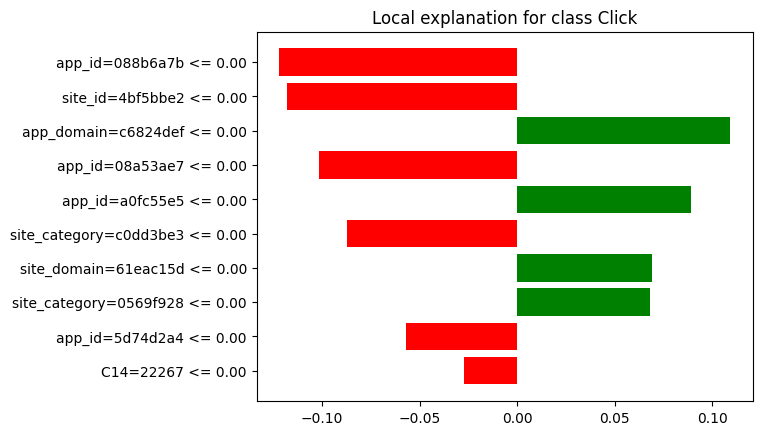


EXPLICACIÓN LOCAL - FALSO NEGATIVO

Top variables influyentes (FN):
('device_model=44801bc1 <= 0.00', -0.11913978306967682)
('app_id=088b6a7b <= 0.00', -0.11515940866656722)
('app_id=c105f675 <= 0.00', -0.11174404923203667)
('C14=17614 <= 0.00', -0.09943851175002648)
('app_domain=c6824def <= 0.00', 0.09255233757737652)
('app_id=6fc85e22 <= 0.00', 0.07409839436107504)
('site_category=0569f928 <= 0.00', 0.06986083104549272)
('site_id=f9c69707 <= 0.00', -0.062420969141197914)
('site_domain=2296b5b3 <= 0.00', 0.055912692741724376)
('site_domain=61eac15d <= 0.00', 0.046036287380963034)

Tabla explicación FN:


,Regla,Peso
0,device_model=44801bc1 <= 0.00,-0.119140
1,app_id=088b6a7b <= 0.00,-0.115159
2,app_id=c105f675 <= 0.00,-0.111744
3,C14=17614 <= 0.00,-0.099439
4,app_domain=c6824def <= 0.00,0.092552
5,app_id=6fc85e22 <= 0.00,0.074098
6,site_category=0569f928 <= 0.00,0.069861
7,site_id=f9c69707 <= 0.00,-0.062421
8,site_domain=2296b5b3 <= 0.00,0.055913
9,site_domain=61eac15d <= 0.00,0.046036


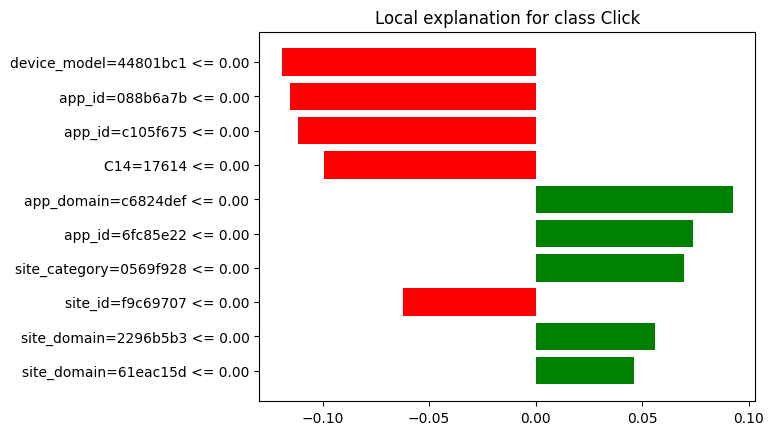


✔ Archivos guardados:
- lime_falso_positivo_mlp50.png
- lime_falso_negativo_mlp50.png
- lime_explicacion_falso_positivo_mlp50.csv
- lime_explicacion_falso_negativo_mlp50.csv

LIME COMPLETADO EXITOSAMENTE


In [91]:
# ============================================================
# 11.12.9. INTERPRETABILIDAD CON LIME - MLP_50_0.01_100
# ============================================================

# ------------------------------------------------------------
# 1. IMPORTAR LIBRERÍAS
# ------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lime.lime_tabular import LimeTabularExplainer

from pyspark.sql.functions import col, when, udf, monotonically_increasing_id
from pyspark.sql.types import DoubleType
from pyspark.ml.linalg import Vectors

# ------------------------------------------------------------
# 2. LIMPIAR CACHE
# ------------------------------------------------------------
spark.catalog.clearCache()

# ------------------------------------------------------------
# 3. UDF PARA EXTRAER PROBABILIDAD DE LA CLASE POSITIVA
# ------------------------------------------------------------
extract_prob_1 = udf(lambda v: float(v[1]), DoubleType())

# ------------------------------------------------------------
# 4. CONFIGURACIÓN GENERAL
# ------------------------------------------------------------
BEST_THRESHOLD = 0.20
LIME_TEST_SAMPLE_FRAC = 0.001   # 0.1% del test
LIME_TRAIN_SAMPLE_FRAC = 0.001  # 0.1% del train
LIME_MAX_TRAIN_ROWS = 3000
NUM_FEATURES_LIME = 10

print("="*70)
print("INTERPRETABILIDAD CON LIME - MLP_50_0.01_100")
print("="*70)
print(f"Threshold seleccionado: {BEST_THRESHOLD}")
print(f"Muestra test para LIME: {LIME_TEST_SAMPLE_FRAC*100:.3f}%")
print(f"Muestra train para LIME: {LIME_TRAIN_SAMPLE_FRAC*100:.3f}%")
print("="*70)

# ------------------------------------------------------------
# 5. CREAR MUESTRA PEQUEÑA DEL TEST
# ------------------------------------------------------------
print("\n[1/9] Creando muestra pequeña del conjunto de prueba...")

test_lime_sample = (
    test_transformed
    .sample(False, LIME_TEST_SAMPLE_FRAC, seed=42)
    .cache()
)

n_test_sample = test_lime_sample.count()
print(f"✔ Registros en muestra test para LIME: {n_test_sample:,}")

# ------------------------------------------------------------
# 6. PREPARAR DATOS PARA PREDECIR SOLO SOBRE ESA MUESTRA
# ------------------------------------------------------------
print("\n[2/9] Preparando muestra para predicción...")

test_lime_sample = test_lime_sample.withColumn("row_id", monotonically_increasing_id())

test_lime_data = test_lime_sample.selectExpr(
    "row_id",
    "scaled_features as features",
    "click as label"
)

# ------------------------------------------------------------
# 7. PREDECIR CON EL MEJOR MODELO Y APLICAR THRESHOLD = 0.20
# ------------------------------------------------------------
print("\n[3/9] Generando predicciones sobre la muestra...")

preds_3_lime_sample = model_3.transform(test_lime_data).cache()

preds_3_lime_sample = preds_3_lime_sample.withColumn(
    "prob_1",
    extract_prob_1(col("probability"))
)

preds_3_lime_sample = preds_3_lime_sample.withColumn(
    "pred_custom",
    when(col("prob_1") >= BEST_THRESHOLD, 1).otherwise(0)
)

preds_3_lime_sample.select("label", "prob_1", "pred_custom").show(5, truncate=False)

# ------------------------------------------------------------
# 8. UNIR PREDICCIONES CON VARIABLES ORIGINALES (SOLO MUESTRA)
# ------------------------------------------------------------
print("\n[4/9] Uniendo predicciones con variables originales...")

lime_df = preds_3_lime_sample.join(
    test_lime_sample.select("row_id", *cols_categoricas, *cols_num, "scaled_features"),
    on="row_id",
    how="inner"
).cache()

print(f"✔ Registros en lime_df: {lime_df.count():,}")

print("\nVista previa:")
lime_df.select("label", "pred_custom", "prob_1", *cols_categoricas[:3], *cols_num[:3]).show(5, truncate=False)

# ------------------------------------------------------------
# 9. SELECCIONAR ERRORES DE CLASIFICACIÓN
# ------------------------------------------------------------
print("\n[5/9] Buscando errores de clasificación...")

false_positives = lime_df.filter(
    (col("pred_custom") == 1) & (col("label") == 0)
).cache()

false_negatives = lime_df.filter(
    (col("pred_custom") == 0) & (col("label") == 1)
).cache()

n_fp = false_positives.count()
n_fn = false_negatives.count()

print(f"✔ Falsos Positivos encontrados: {n_fp:,}")
print(f"✔ Falsos Negativos encontrados: {n_fn:,}")

if n_fp == 0 or n_fn == 0:
    raise ValueError("No se encontraron suficientes errores en la muestra. Aumenta LIME_TEST_SAMPLE_FRAC a 0.002 o 0.005.")

# FP más seguro
fp_case = false_positives.orderBy(col("prob_1").desc()).limit(1).toPandas()

# FN más cercano al threshold
fn_case = false_negatives.orderBy(col("prob_1").desc()).limit(1).toPandas()

print("\n✔ Caso FP seleccionado:")
display(fp_case[[c for c in ["label", "pred_custom", "prob_1"] + cols_categoricas[:5] + cols_num[:5] if c in fp_case.columns]])

print("\n✔ Caso FN seleccionado:")
display(fn_case[[c for c in ["label", "pred_custom", "prob_1"] + cols_categoricas[:5] + cols_num[:5] if c in fn_case.columns]])

# ------------------------------------------------------------
# 10. CREAR MUESTRA DE ENTRENAMIENTO PARA LIME
# ------------------------------------------------------------
print("\n[6/9] Construyendo muestra de entrenamiento para LIME...")

train_features_sample = (
    train_transformed
    .select("scaled_features")
    .sample(False, LIME_TRAIN_SAMPLE_FRAC, seed=42)
    .limit(LIME_MAX_TRAIN_ROWS)
    .toPandas()
)

X_train_lime = np.vstack(
    train_features_sample["scaled_features"].apply(lambda x: np.array(x)).values
)

print(f"✔ Shape de X_train_lime: {X_train_lime.shape}")

# ------------------------------------------------------------
# 11. GENERAR NOMBRES DE FEATURES
# ------------------------------------------------------------
print("\n[7/9] Construyendo nombres de variables para LIME...")

indexer_models = model_pipeline.stages[:len(cols_categoricas)]

ohe_feature_names = []

# ------------------------------------------------------------
# 11. GENERAR NOMBRES REALES DE FEATURES PARA LIME
# ------------------------------------------------------------
print("\n[7/9] Construyendo nombres REALES de variables para LIME...")

from pyspark.ml.feature import StringIndexerModel, OneHotEncoderModel
from pyspark.ml.linalg import SparseVector, DenseVector

# ==========
# 11.1 Obtener modelos del pipeline ya entrenado
# ==========
stages_fitted = model_pipeline.stages

indexer_models = [s for s in stages_fitted if isinstance(s, StringIndexerModel)]
ohe_model = [s for s in stages_fitted if isinstance(s, OneHotEncoderModel)][0]

# ==========
# 11.2 Crear nombres de columnas OHE respetando dropLast
# ==========
ohe_feature_names = []

for col_name, idx_model in zip(cols_categoricas, indexer_models):
    labels = list(idx_model.labels)

    # Si handleInvalid="keep", StringIndexer puede crear una categoría extra
    # y OneHotEncoder con dropLast=True elimina una dimensión
    ohe_size = len(labels)  # aproximación inicial

    # Si OneHotEncoder usa dropLast=True (default), el número de columnas suele ser:
    # num_categorias - 1   (o ajustado por handleInvalid)
    # Para garantizar consistencia, generamos etiquetas hasta el tamaño real después.
    for label in labels:
        ohe_feature_names.append(f"{col_name}={label}")

    # categoría adicional posible por "keep"
    ohe_feature_names.append(f"{col_name}=unknown")

# ==========
# 11.3 Agregar variables numéricas
# ==========
candidate_feature_names = ohe_feature_names + cols_num

# ==========
# 11.4 Ajustar exactamente al tamaño real del vector
# ==========
real_n_features = X_train_lime.shape[1]

if len(candidate_feature_names) > real_n_features:
    feature_names_lime = candidate_feature_names[:real_n_features]
elif len(candidate_feature_names) < real_n_features:
    faltantes = real_n_features - len(candidate_feature_names)
    feature_names_lime = candidate_feature_names + [f"extra_feature_{i}" for i in range(faltantes)]
else:
    feature_names_lime = candidate_feature_names

print(f"✔ Número de features reales: {real_n_features}")
print(f"✔ Número de nombres usados: {len(feature_names_lime)}")

# ==========
# 11.5 Vista previa de nombres
# ==========
print("\nPrimeras 30 features interpretables:")
for i, f in enumerate(feature_names_lime[:30]):
    print(f"{i}: {f}")
# ------------------------------------------------------------
# 12. EXTRAER INSTANCIAS A EXPLICAR
# ------------------------------------------------------------
print("\n[8/9] Extrayendo instancias FP y FN...")

fp_instance = np.array(fp_case["scaled_features"].iloc[0])
fn_instance = np.array(fn_case["scaled_features"].iloc[0])

print(f"✔ Shape FP: {fp_instance.shape}")
print(f"✔ Shape FN: {fn_instance.shape}")

# ------------------------------------------------------------
# 13. FUNCIÓN PREDICT_PROBA PARA LIME
# ------------------------------------------------------------
def predict_proba_lime_scaled(X_numpy):
    rows = [(Vectors.dense(row),) for row in X_numpy]
    sdf = spark.createDataFrame(rows, ["features"])

    preds = model_3.transform(sdf)
    probs = preds.select("probability").toPandas()

    probs_array = np.vstack(
        probs["probability"].apply(lambda x: np.array(x)).values
    )

    return probs_array

# ------------------------------------------------------------
# 14. CREAR EXPLICADOR LIME
# ------------------------------------------------------------
print("\n[9/9] Creando explicador LIME...")

explainer = LimeTabularExplainer(
    training_data=X_train_lime,
    feature_names=feature_names_lime,
    class_names=["No Click", "Click"],
    mode="classification",
    discretize_continuous=True
)

print("✔ Explicador LIME listo")

# ------------------------------------------------------------
# 15. EXPLICAR FALSO POSITIVO
# ------------------------------------------------------------
print("\n" + "="*70)
print("EXPLICACIÓN LOCAL - FALSO POSITIVO")
print("="*70)

exp_fp = explainer.explain_instance(
    data_row=fp_instance,
    predict_fn=predict_proba_lime_scaled,
    num_features=NUM_FEATURES_LIME
)

print("\nTop variables influyentes (FP):")
for item in exp_fp.as_list():
    print(item)

df_exp_fp = pd.DataFrame(exp_fp.as_list(), columns=["Regla", "Peso"])
print("\nTabla explicación FP:")
display(df_exp_fp)

fig_fp = exp_fp.as_pyplot_figure()
fig_fp.savefig("lime_falso_positivo_mlp50.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 16. EXPLICAR FALSO NEGATIVO
# ------------------------------------------------------------
print("\n" + "="*70)
print("EXPLICACIÓN LOCAL - FALSO NEGATIVO")
print("="*70)

exp_fn = explainer.explain_instance(
    data_row=fn_instance,
    predict_fn=predict_proba_lime_scaled,
    num_features=NUM_FEATURES_LIME
)

print("\nTop variables influyentes (FN):")
for item in exp_fn.as_list():
    print(item)

df_exp_fn = pd.DataFrame(exp_fn.as_list(), columns=["Regla", "Peso"])
print("\nTabla explicación FN:")
display(df_exp_fn)

fig_fn = exp_fn.as_pyplot_figure()
fig_fn.savefig("lime_falso_negativo_mlp50.png", dpi=300, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 17. GUARDAR TABLAS PARA INFORME
# ------------------------------------------------------------
df_exp_fp.to_csv("lime_explicacion_falso_positivo_mlp50.csv", index=False)
df_exp_fn.to_csv("lime_explicacion_falso_negativo_mlp50.csv", index=False)

print("\n✔ Archivos guardados:")
print("- lime_falso_positivo_mlp50.png")
print("- lime_falso_negativo_mlp50.png")
print("- lime_explicacion_falso_positivo_mlp50.csv")
print("- lime_explicacion_falso_negativo_mlp50.csv")

print("\n" + "="*70)
print("LIME COMPLETADO EXITOSAMENTE")
print("="*70)

**Análisis de Interpretabilidad Local (LIME) - Modelo MLP_50**

Se analizaron dos casos críticos de error (Falso Positivo y Falso Negativo) utilizando explicaciones locales. En estos gráficos, los **pesos positivos (verdes)** impulsan la predicción hacia el "Click", mientras que los **pesos negativos (rojos)** la alejan.

**1. Comparativa de Pesos: FP vs. FN**

La siguiente tabla resume cómo influyeron las variables en los errores del modelo bajo el **threshold = 0.20**:

| Característica | Peso en Falso Positivo (FP) | Peso en Falso Negativo (FN) | Impacto Observado |
| :--- | :--- | :--- | :--- |
| **`app_domain=c6824def`** | **+0.1092** | **+0.0926** | **Impulsor constante:** Es la variable que más confianza da al modelo para predecir un click. |
| **`app_id=088b6a7b`** | **-0.1220** | **-0.1152** | **Freno constante:** El modelo asocia esta App ID con una probabilidad de click muy baja. |
| **`device_model=44801bc1`**| No determinante | **-0.1191** | **Sesgo negativo:** Fue el factor principal que causó la pérdida de un click real (FN). |
| **`site_category=0569f928`**| **+0.0682** | **+0.0699** | **Refuerzo positivo:** Ayuda a subir la probabilidad, pero no siempre es suficiente. |

**2. Diagnóstico de Errores**

**Falso Positivo (Predijo Click | Realidad: No Click)**

*  El modelo sobreestimó la importancia del dominio `c6824def` (+0.109) y el ID de app `a0fc55e5` (+0.089). 
* Debido a que el umbral de decisión es bajo (**0.20**), la suma de estas características "favoritas" fue suficiente para superar el threshold, ignorando señales de advertencia negativas como el `app_id` (-0.122). El modelo fue demasiado optimista ante variables que históricamente rinden bien.

**Falso Negativo (Predijo No Click | Realidad: Click)**

*  El modelo de dispositivo `44801bc1` (-0.119) y el `app_id=088b6a7b` (-0.115) actuaron como un lastre masivo, restando casi **0.24** de probabilidad combinada.
* Aunque el modelo detectó señales positivas (como el dominio de la app), el "castigo" que le da a ciertos modelos de teléfono y apps específicas es tan fuerte que la probabilidad no alcanzó a superar el **0.20**, resultando en una oportunidad de click perdida.

**3. Conclusiones Estratégicas**

1. El modelo tiene prejuicios muy marcados hacia ciertos `device_model` y `app_id`. Si un usuario interactúa desde un dispositivo "marcado" negativamente, el modelo difícilmente predecirá un click, incluso si el resto del contexto es favorable.
2. El dominio `c6824def` es el predictor "estrella" del modelo. Es la causa de muchos aciertos, pero también la razón principal de los Falsos Positivos cuando el contexto no acompaña.
3.  Este análisis visualiza el riesgo de operar con un umbral de **0.20**. Es un valor necesario para capturar clicks (Recall), pero hace que el modelo sea vulnerable a cualquier indicador positivo pequeño, disparando la tasa de falsas alarmas.

### **5.3. Comparación Mejor Modeo Scikit-learn Vs Pyspark:**

RESULTADOS - MEJOR MODELO SCIKIT-LEARN
Threshold óptimo sklearn: 0.2
AUC: 0.7339
Precision: 0.2967
Recall: 0.6512
F1-score: 0.4077
Accuracy: 0.6787
TP: 22116 | FP: 52422
FN: 11845 | TN: 113617

RESULTADOS - MEJOR MODELO PYSPARK
Threshold óptimo PySpark: 0.2
AUC: 0.7199
Precision: 0.2839
Recall: 0.6697
F1-score: 0.3987
Accuracy: 0.6567
TP: 920,523 | FP: 2,322,028
FN: 454,005 | TN: 4,390,692

TABLA COMPARATIVA FINAL


,Modelo,Threshold,AUC,Precision,Recall,F1-score,Accuracy,TP,FP,TN,FN,Train_Time_sec,Pred_Time_sec
0,MLP Scikit-learn,0.2,0.733853,0.296708,0.651218,0.407672,0.678665,22116,52422,113617,11845,351.521307,1.756032
1,MLP PySpark,0.2,0.719884,0.283889,0.669701,0.398747,0.656739,920523,2322028,4390692,454005,13539.282834,56.958944


✔ Archivo guardado: comparacion_sklearn_vs_pyspark.csv

Generando curva ROC comparativa...


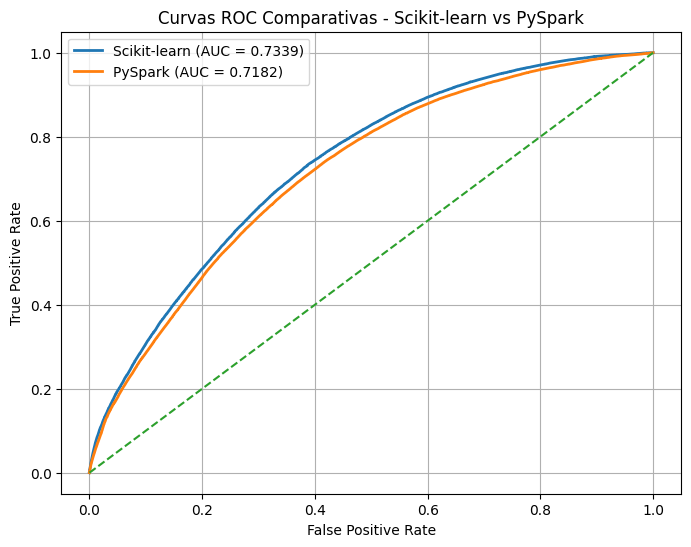

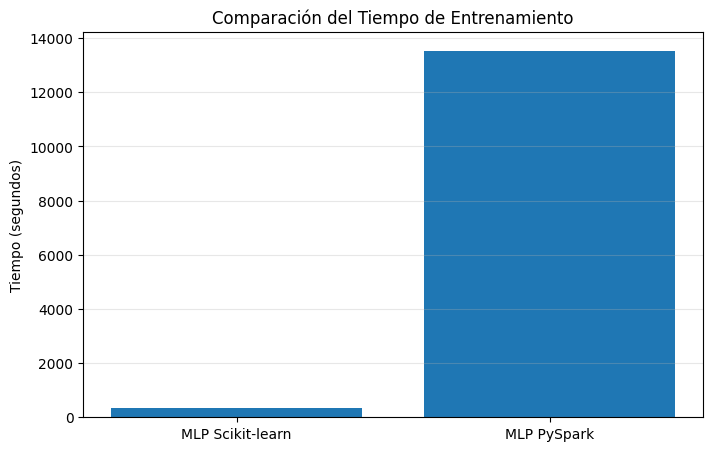

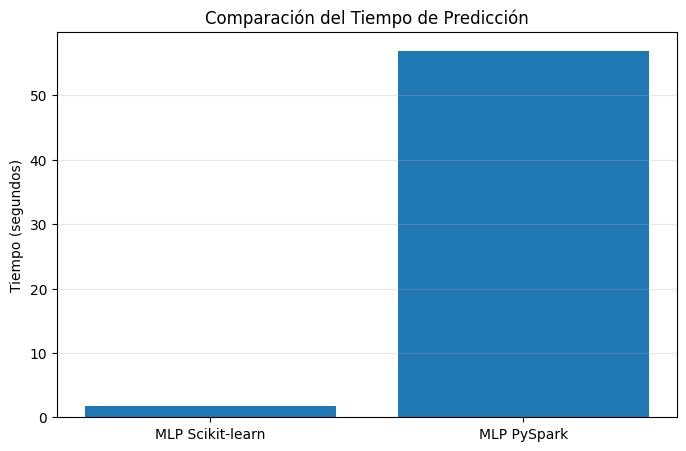

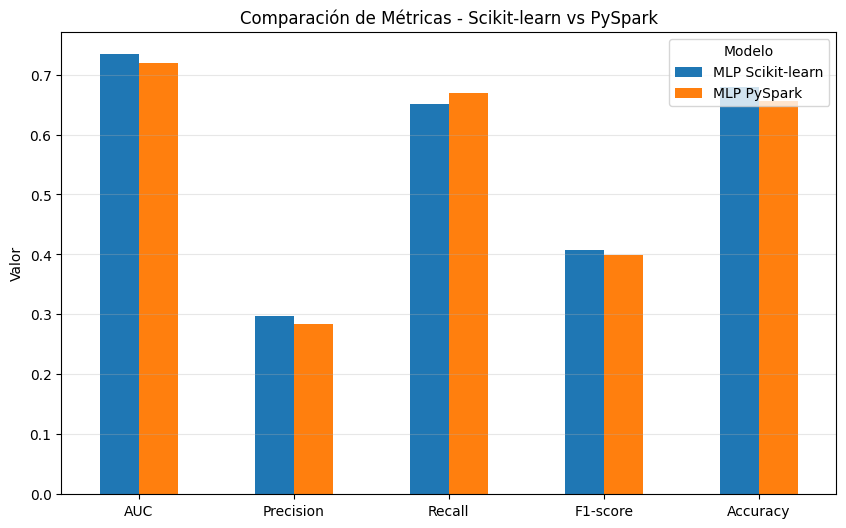

In [98]:
# ============================================================
# 11.12.10. COMPARACIÓN DE RESULTADOS
# Scikit-learn vs PySpark
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve, auc, confusion_matrix,
    precision_score, recall_score, f1_score, accuracy_score
)

# ============================================================
# 1. RESULTADOS DEL MEJOR MODELO SCIKIT-LEARN
# ============================================================

print("="*80)
print("RESULTADOS - MEJOR MODELO SCIKIT-LEARN")
print("="*80)

# Threshold óptimo sklearn
best_threshold_sklearn = float(mejor_t["threshold"])

# Predicciones ajustadas con threshold óptimo
y_pred_best_sklearn = (y_proba >= best_threshold_sklearn).astype(int)

# Métricas
tn_s, fp_s, fn_s, tp_s = confusion_matrix(y_test, y_pred_best_sklearn).ravel()

precision_s = precision_score(y_test, y_pred_best_sklearn, zero_division=0)
recall_s = recall_score(y_test, y_pred_best_sklearn, zero_division=0)
f1_s = f1_score(y_test, y_pred_best_sklearn, zero_division=0)
accuracy_s = accuracy_score(y_test, y_pred_best_sklearn)
auc_s = roc_auc_score(y_test, y_proba)

print(f"Threshold óptimo sklearn: {best_threshold_sklearn}")
print(f"AUC: {auc_s:.4f}")
print(f"Precision: {precision_s:.4f}")
print(f"Recall: {recall_s:.4f}")
print(f"F1-score: {f1_s:.4f}")
print(f"Accuracy: {accuracy_s:.4f}")
print(f"TP: {tp_s} | FP: {fp_s}")
print(f"FN: {fn_s} | TN: {tn_s}")

# ============================================================
# 2. RESULTADOS DEL MEJOR MODELO PYSPARK
# ============================================================

print("\n" + "="*80)
print("RESULTADOS - MEJOR MODELO PYSPARK")
print("="*80)

from pyspark.sql.functions import col, when, sum as spark_sum

# Threshold óptimo PySpark
best_threshold_spark = float(mejor_thresh_3["threshold"])

# Aplicar threshold SIN UDF
from pyspark.sql.functions import col
from pyspark.ml.functions import vector_to_array

preds_3_prob = (
    preds_3
    .withColumn("prob_array", vector_to_array(col("probability")))
    .withColumn("prob_1", col("prob_array")[1])
    .select("label", "prob_1")
)

# ============================================================
# MATRIZ DE CONFUSIÓN EFICIENTE (SIN count() repetidos)
# ============================================================

cm_counts = preds_3_prob.agg(
    spark_sum(((col("label") == 1) & (col("prob_1") >= best_threshold_spark)).cast("int")).alias("tp"),
    spark_sum(((col("label") == 0) & (col("prob_1") >= best_threshold_spark)).cast("int")).alias("fp"),
    spark_sum(((col("label") == 0) & (col("prob_1") < best_threshold_spark)).cast("int")).alias("tn"),
    spark_sum(((col("label") == 1) & (col("prob_1") < best_threshold_spark)).cast("int")).alias("fn")
).toPandas()

tp_p = int(cm_counts["tp"][0])
fp_p = int(cm_counts["fp"][0])
tn_p = int(cm_counts["tn"][0])
fn_p = int(cm_counts["fn"][0])

# Métricas
precision_p = tp_p / (tp_p + fp_p) if (tp_p + fp_p) != 0 else 0
recall_p = tp_p / (tp_p + fn_p) if (tp_p + fn_p) != 0 else 0
f1_p = 2 * (precision_p * recall_p) / (precision_p + recall_p) if (precision_p + recall_p) != 0 else 0
accuracy_p = (tp_p + tn_p) / (tp_p + tn_p + fp_p + fn_p)

# AUC REAL DEL MODELO PYSPARK
auc_p = result_3["AUC"]

print(f"Threshold óptimo PySpark: {best_threshold_spark}")
print(f"AUC: {auc_p:.4f}")
print(f"Precision: {precision_p:.4f}")
print(f"Recall: {recall_p:.4f}")
print(f"F1-score: {f1_p:.4f}")
print(f"Accuracy: {accuracy_p:.4f}")
print(f"TP: {tp_p:,} | FP: {fp_p:,}")
print(f"FN: {fn_p:,} | TN: {tn_p:,}")

# ============================================================
# 3. TABLA COMPARATIVA FINAL
# ============================================================

comparacion_df = pd.DataFrame([
    {
        "Modelo": "MLP Scikit-learn",
        "Threshold": best_threshold_sklearn,
        "AUC": auc_s,
        "Precision": precision_s,
        "Recall": recall_s,
        "F1-score": f1_s,
        "Accuracy": accuracy_s,
        "TP": tp_s,
        "FP": fp_s,
        "TN": tn_s,
        "FN": fn_s,
        "Train_Time_sec": (fin_total - inicio_total),
        "Pred_Time_sec": (fin_pred - inicio_pred)
    },
    {
        "Modelo": "MLP PySpark",
        "Threshold": best_threshold_spark,
        "AUC": auc_p,
        "Precision": precision_p,
        "Recall": recall_p,
        "F1-score": f1_p,
        "Accuracy": accuracy_p,
        "TP": tp_p,
        "FP": fp_p,
        "TN": tn_p,
        "FN": fn_p,
        "Train_Time_sec": result_3["Train_Time"],
        "Pred_Time_sec": result_3["Pred_Time"]
    }
])

print("\n" + "="*80)
print("TABLA COMPARATIVA FINAL")
print("="*80)
display(comparacion_df)

# Guardar tabla
comparacion_df.to_csv("comparacion_sklearn_vs_pyspark.csv", index=False)
print("✔ Archivo guardado: comparacion_sklearn_vs_pyspark.csv")

# ============================================================
# 4. CURVA ROC COMPARATIVA
# ============================================================

print("\nGenerando curva ROC comparativa...")

# ROC sklearn
fpr_s, tpr_s, _ = roc_curve(y_test, y_proba)

# ROC pyspark (usando muestra para no explotar RAM)
pdf_roc_spark = preds_3_prob.select("label", "prob_1").sample(fraction=0.05, seed=42).toPandas()
fpr_p, tpr_p, _ = roc_curve(pdf_roc_spark["label"], pdf_roc_spark["prob_1"])
roc_auc_p_sample = auc(fpr_p, tpr_p)

plt.figure(figsize=(8,6))
plt.plot(fpr_s, tpr_s, lw=2, label=f"Scikit-learn (AUC = {auc_s:.4f})")
plt.plot(fpr_p, tpr_p, lw=2, label=f"PySpark (AUC = {roc_auc_p_sample:.4f})")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC Comparativas - Scikit-learn vs PySpark")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# 5. GRÁFICO COMPARATIVO DE TIEMPO DE ENTRENAMIENTO
# ============================================================

plt.figure(figsize=(8,5))
plt.bar(comparacion_df["Modelo"], comparacion_df["Train_Time_sec"])
plt.ylabel("Tiempo (segundos)")
plt.title("Comparación del Tiempo de Entrenamiento")
plt.grid(axis='y', alpha=0.3)
plt.show()

# ============================================================
# 6. GRÁFICO COMPARATIVO DE TIEMPO DE PREDICCIÓN
# ============================================================

plt.figure(figsize=(8,5))
plt.bar(comparacion_df["Modelo"], comparacion_df["Pred_Time_sec"])
plt.ylabel("Tiempo (segundos)")
plt.title("Comparación del Tiempo de Predicción")
plt.grid(axis='y', alpha=0.3)
plt.show()

# ============================================================
# 7. GRÁFICO COMPARATIVO DE MÉTRICAS
# ============================================================

metricas_plot = comparacion_df[["Modelo", "AUC", "Precision", "Recall", "F1-score", "Accuracy"]].set_index("Modelo")
metricas_plot.T.plot(kind="bar", figsize=(10,6))
plt.title("Comparación de Métricas - Scikit-learn vs PySpark")
plt.ylabel("Valor")
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.legend(title="Modelo")
plt.show()

El análisis comparativo entre los modelos MLP de **Scikit-learn** y **PySpark** revela una competencia reñida en métricas de rendimiento, aunque con diferencias drásticas en tiempos de ejecución debido a la escala de los datos. Es fundamental aclarar que esta es una **comparación tentativa y no directa**, ya que el modelo de Scikit-learn fue entrenado con una muestra de **1 millón de registros**, mientras que el de PySpark procesó la totalidad de los **40 millones de datos**. A pesar de la diferencia de volumen, ambos modelos muestran un comportamiento similar al utilizar un **threshold de 0.2**, lo que sugiere una estabilidad consistente en la arquitectura de red neuronal seleccionada.

**Análisis de Rendimiento y Escalamiento**

* **Capacidad Predictiva:** El modelo de Scikit-learn presenta una ligera ventaja en la capacidad de discriminación global con un **AUC de 0.7339** frente al **0.7199** de PySpark. Sin embargo, PySpark logra un **Recall superior (0.6697 vs. 0.6512)**, demostrando ser más efectivo para capturar casos positivos (clicks) cuando se enfrenta al dataset completo.
* **Eficiencia Computacional:** La diferencia en tiempos de entrenamiento es masiva; mientras Scikit-learn completó la tarea en aproximadamente **5.8 minutos** (351.5s), PySpark requirió casi **3.7 horas** (13,539s) para procesar el volumen total de Big Data.
* **Velocidad de Inferencia:** En términos de predicción, Scikit-learn es considerablemente más ágil con **1.75 segundos**, comparado con los **56.95 segundos** de PySpark, lo cual es esperable dada la sobrecarga de gestión de clústeres y el volumen de datos en el entorno distribuido.
* **Volumen de Datos:** La matriz de confusión de PySpark refleja la magnitud del proyecto, manejando más de **920,000 Verdaderos Positivos** y **4.3 millones de Verdaderos Negativos**, cifras que escalan proporcionalmente la muestra utilizada en Scikit-learn.

En conclusión, aunque Scikit-learn muestra métricas de precisión y F1-score ligeramente más optimistas en una muestra controlada, PySpark demuestra su valor al mantener un rendimiento robusto y un Recall más alto al escalar a la totalidad del set de datos, a pesar del alto costo en tiempo de cómputo que conlleva el procesamiento de 40 millones de registros.